# Loan Default Risk Analysis & Prediction
### Statistical Analysis, Feature Engineering, and Machine Learning for Credit Risk Assessment

---

## Business Problem

A lending institution needs to assess the creditworthiness of loan applicants **before loan approval**.  
The goal is to identify borrowers who are likely to default — enabling the bank to make better lending decisions, reduce credit losses, and allocate risk appropriately.

**Key business questions:**
- What borrower characteristics are associated with default?
- Which factors significantly influence loan repayment behaviour?
- Can we predict default risk at the time of loan application?
- What actions can the bank take to reduce credit risk?

**Model evaluation priority:** Recall — because missing a real defaulter (False Negative) is far more costly to the bank than rejecting a good borrower (False Positive).

---

**Dataset:** Lending Club Loan Dataset (~10,000 loans)  
**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn, SciPy, Scikit-learn

In [415]:
# Core libraries
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical testing
from scipy import stats

# Machine learning
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay, RocCurveDisplay,precision_recall_curve)

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid')

print("All libraries imported successfully")

All libraries imported successfully


In [416]:
df = pd.read_csv('loans_full_schema.csv')
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (10000, 56)


,Unnamed: 0,emp_title,emp_length,state,homeownership,annual_income,verified_income,debt_to_income,annual_income_joint,verification_income_joint,debt_to_income_joint,delinq_2y,months_since_last_delinq,earliest_credit_line,inquiries_last_12m,total_credit_lines,open_credit_lines,total_credit_limit,total_credit_utilized,num_collections_last_12m,num_historical_failed_to_pay,months_since_90d_late,current_accounts_delinq,total_collection_amount_ever,current_installment_accounts,accounts_opened_24m,months_since_last_credit_inquiry,num_satisfactory_accounts,num_accounts_120d_past_due,num_accounts_30d_past_due,num_active_debit_accounts,total_debit_limit,num_total_cc_accounts,num_open_cc_accounts,num_cc_carrying_balance,num_mort_accounts,account_never_delinq_percent,tax_liens,public_record_bankrupt,loan_purpose,application_type,loan_amount,term,interest_rate,installment,grade,sub_grade,issue_month,loan_status,initial_listing_status,disbursement_method,balance,paid_total,paid_principal,paid_interest,paid_late_fees
0,1,global config engineer,3.00,NJ,MORTGAGE,90000.00,Verified,18.01,NaN,NaN,NaN,0,38.00,2001,6,28,10,70795,38767,0,0,38.00,0,1250,2,5,5.00,10,0.00,0,2,11100,14,8,6,1,92.90,0,0,moving,individual,28000,60,14.07,652.53,C,C3,Mar-2018,Current,whole,Cash,27015.86,1999.33,984.14,1015.19,0.00
1,2,warehouse office clerk,10.00,HI,RENT,40000.00,Not Verified,5.04,NaN,NaN,NaN,0,NaN,1996,1,30,14,28800,4321,0,1,NaN,0,0,0,11,8.00,14,0.00,0,3,16500,24,14,4,0,100.00,0,1,debt_consolidation,individual,5000,36,12.61,167.54,C,C1,Feb-2018,Current,whole,Cash,4651.37,499.12,348.63,150.49,0.00
2,3,assembly,3.00,WI,RENT,40000.00,Source Verified,21.15,NaN,NaN,NaN,0,28.00,2006,4,31,10,24193,16000,0,0,28.00,0,432,1,13,7.00,10,0.00,0,3,4300,14,8,6,0,93.50,0,0,other,individual,2000,36,17.09,71.40,D,D1,Feb-2018,Current,fractional,Cash,1824.63,281.80,175.37,106.43,0.00
3,4,customer service,1.00,PA,RENT,30000.00,Not Verified,10.16,NaN,NaN,NaN,0,NaN,2007,0,4,4,25400,4997,0,1,NaN,0,0,1,1,15.00,4,0.00,0,2,19400,3,3,2,0,100.00,1,0,debt_consolidation,individual,21600,36,6.72,664.19,A,A3,Jan-2018,Current,whole,Cash,18853.26,3312.89,2746.74,566.15,0.00
4,5,security supervisor,10.00,CA,RENT,35000.00,Verified,57.96,57000.00,Verified,37.66,0,NaN,2008,7,22,16,69839,52722,0,0,NaN,0,0,1,6,4.00,16,0.00,0,10,32700,20,15,13,0,100.00,0,0,credit_card,joint,23000,36,14.07,786.87,C,C3,Mar-2018,Current,whole,Cash,21430.15,2324.65,1569.85,754.80,0.00


## Data Exploration

Before moving to data cleaning or EDA, I will do some data exploration to
understand the data better so that I can take measured steps during the
cleaning process.

I will look at all the columns with their data types to understand what
each column actually represents. To understand what these columns mean
in context, I will look at the top five rows and also a random sample of
5 rows to spot any immediate patterns or bias.

I will then run statistical summaries to understand the distribution of
the data, followed by a missing value check to know where the data gaps
actually exist.

In [417]:
df.columns.tolist()
df.dtypes

,0
Unnamed: 0,int64
emp_title,object
emp_length,float64
state,object
homeownership,object
annual_income,float64
verified_income,object
debt_to_income,float64
annual_income_joint,float64
verification_income_joint,object


In [418]:
df.sample(5)

,Unnamed: 0,emp_title,emp_length,state,homeownership,annual_income,verified_income,debt_to_income,annual_income_joint,verification_income_joint,debt_to_income_joint,delinq_2y,months_since_last_delinq,earliest_credit_line,inquiries_last_12m,total_credit_lines,open_credit_lines,total_credit_limit,total_credit_utilized,num_collections_last_12m,num_historical_failed_to_pay,months_since_90d_late,current_accounts_delinq,total_collection_amount_ever,current_installment_accounts,accounts_opened_24m,months_since_last_credit_inquiry,num_satisfactory_accounts,num_accounts_120d_past_due,num_accounts_30d_past_due,num_active_debit_accounts,total_debit_limit,num_total_cc_accounts,num_open_cc_accounts,num_cc_carrying_balance,num_mort_accounts,account_never_delinq_percent,tax_liens,public_record_bankrupt,loan_purpose,application_type,loan_amount,term,interest_rate,installment,grade,sub_grade,issue_month,loan_status,initial_listing_status,disbursement_method,balance,paid_total,paid_principal,paid_interest,paid_late_fees
9205,9206,senior loan officer,3.00,MI,MORTGAGE,80000.00,Verified,5.24,NaN,NaN,NaN,2,12.00,2013,2,10,8,160084,8178,0,0,NaN,0,97,1,5,5.00,8,0.00,0,1,3200,6,6,4,1,80.00,0,0,debt_consolidation,individual,28000,60,16.02,681.21,C,C5,Jan-2018,Current,whole,Cash,26421.36,3493.27,1578.64,1914.63,0.00
124,125,owner,3.00,TN,RENT,42500.00,Not Verified,18.55,NaN,NaN,NaN,0,NaN,2010,1,7,6,41886,27474,0,0,NaN,0,0,3,1,5.00,6,0.00,0,2,5800,3,3,3,0,100.00,0,0,credit_card,individual,6000,36,7.35,186.23,A,A4,Jan-2018,Current,whole,Cash,5243.39,928.70,756.61,172.09,0.00
8520,8521,maintenance,10.00,NY,RENT,40000.00,Source Verified,14.58,120000.00,Not Verified,8.29,0,NaN,2002,0,25,13,56285,16738,0,0,NaN,0,0,1,3,NaN,13,0.00,0,3,33300,24,12,8,0,100.00,0,0,credit_card,joint,20000,36,6.07,609.08,A,A2,Mar-2018,Current,whole,Cash,18468.54,1820.50,1531.46,289.04,0.00
4848,4849,engineer,6.00,FL,MORTGAGE,70480.00,Verified,37.08,111900.00,Verified,25.32,0,NaN,2006,5,21,11,341340,116079,0,0,NaN,0,0,4,5,5.00,11,0.00,0,2,30000,8,6,5,1,100.00,0,0,credit_card,joint,34000,60,12.61,766.84,C,C1,Mar-2018,Current,whole,Cash,32758.37,2276.70,1241.63,1035.07,0.00
3927,3928,teacher,10.00,OH,MORTGAGE,75000.00,Not Verified,23.83,NaN,NaN,NaN,0,30.00,1987,0,27,15,200903,62782,0,0,NaN,0,0,5,3,13.00,15,0.00,0,4,35500,13,8,6,2,96.20,0,0,medical,individual,9600,36,9.44,307.25,B,B1,Feb-2018,Current,whole,Cash,8662.08,1223.97,937.92,286.05,0.00


In [419]:
df.describe()

,Unnamed: 0,emp_length,annual_income,debt_to_income,annual_income_joint,debt_to_income_joint,delinq_2y,months_since_last_delinq,earliest_credit_line,inquiries_last_12m,total_credit_lines,open_credit_lines,total_credit_limit,total_credit_utilized,num_collections_last_12m,num_historical_failed_to_pay,months_since_90d_late,current_accounts_delinq,total_collection_amount_ever,current_installment_accounts,accounts_opened_24m,months_since_last_credit_inquiry,num_satisfactory_accounts,num_accounts_120d_past_due,num_accounts_30d_past_due,num_active_debit_accounts,total_debit_limit,num_total_cc_accounts,num_open_cc_accounts,num_cc_carrying_balance,num_mort_accounts,account_never_delinq_percent,tax_liens,public_record_bankrupt,loan_amount,term,interest_rate,installment,balance,paid_total,paid_principal,paid_interest,paid_late_fees
count,10000.00,9183.00,10000.00,9976.00,1495.00,1495.00,10000.00,4342.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,2285.00,10000.00,10000.00,10000.00,10000.00,8729.00,10000.00,9682.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00
mean,5000.50,5.93,79222.15,19.31,127914.57,19.98,0.22,36.76,2001.29,1.96,22.68,11.40,183606.23,51049.06,0.01,0.17,46.11,0.00,184.33,2.66,4.38,7.34,11.38,0.00,0.00,3.60,27357.41,13.03,8.10,5.23,1.38,94.65,0.04,0.12,16361.92,43.27,12.43,476.21,14458.92,2494.23,1894.45,599.67,0.12
std,2886.90,3.70,64734.29,15.00,70168.38,8.05,0.68,21.63,7.80,2.38,11.89,5.87,187632.71,53636.73,0.13,0.69,21.75,0.01,2206.39,2.94,3.16,5.98,5.86,0.00,0.01,2.43,26570.16,7.87,4.91,3.33,1.72,9.16,0.59,0.34,10301.96,11.03,5.00,294.85,9964.56,3958.23,3884.41,517.33,1.81
min,1.00,0.00,0.00,0.00,19200.00,0.32,0.00,1.00,1963.00,0.00,2.00,0.00,0.00,0.00,0.00,0.00,2.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,2.00,0.00,0.00,0.00,14.30,0.00,0.00,1000.00,36.00,5.31,30.75,0.00,0.00,0.00,0.00,0.00
25%,2500.75,2.00,45000.00,11.06,86833.50,14.16,0.00,19.00,1997.00,0.00,14.00,7.00,51593.75,19185.50,0.00,0.00,29.00,0.00,0.00,1.00,2.00,2.00,7.00,0.00,0.00,2.00,10000.00,7.00,5.00,3.00,0.00,92.60,0.00,0.00,8000.00,36.00,9.43,256.04,6679.07,928.70,587.10,221.76,0.00
50%,5000.50,6.00,65000.00,17.57,113000.00,19.72,0.00,34.00,2003.00,1.00,21.00,10.00,114667.00,36927.00,0.00,0.00,47.00,0.00,0.00,2.00,4.00,6.00,10.00,0.00,0.00,3.00,19500.00,11.00,7.00,5.00,1.00,100.00,0.00,0.00,14500.00,36.00,11.98,398.42,12379.49,1563.30,984.99,446.14,0.00
75%,7500.25,10.00,95000.00,25.00,151545.50,25.50,0.00,53.00,2006.00,3.00,29.00,14.00,267550.00,65421.00,0.00,0.00,63.00,0.00,0.00,3.00,6.00,11.00,14.00,0.00,0.00,5.00,36100.00,17.00,10.00,7.00,2.00,100.00,0.00,0.00,24000.00,60.00,15.05,644.69,20690.18,2616.01,1694.56,825.42,0.00
max,10000.00,10.00,2300000.00,469.09,1100000.00,39.98,13.00,118.00,2015.00,29.00,87.00,51.00,3386034.00,942456.00,3.00,52.00,128.00,1.00,199308.00,35.00,29.00,24.00,51.00,0.00,1.00,32.00,386700.00,66.00,46.00,43.00,14.00,100.00,52.00,3.00,40000.00,60.00,30.94,1566.59,40000.00,41630.44,40000.00,4216.44,52.98


In [420]:
df.isnull().sum()

,0
Unnamed: 0,0
emp_title,833
emp_length,817
state,0
homeownership,0
annual_income,0
verified_income,0
debt_to_income,24
annual_income_joint,8505
verification_income_joint,8545


**Key findings from exploration:**
- Dataset shape: 10,000 rows, 56 columns
- Target variable: `loan_status` — 178 at-risk borrowers vs 9,822 non-default
- Several columns had structural missing values, not random gaps
- Post-loan repayment columns confirmed as data leakage
- Joint application columns (`annual_income_joint`, `verification_income_joint`,
`debt_to_income_joint`) showed 8,505 missing values out of 10,000 rows in the
missing value check, confirming that most loans are individual applications

## Data Cleaning

Before moving to EDA, I will clean the dataset based on the findings
from the exploration phase.

I will separate the columns into three buckets, where each bucket helps
me identify how each column needs to be handled.

**Bucket 1 — Columns to Drop**
These columns will be dropped for three reasons:

1. They will cause data leakage when training the model — columns like
`paid_total`, `balance`, `paid_interest` only exist after the loan has
already been issued and repaid

2. They are redundant — `grade` and `sub_grade` are lender-assigned risk
categories that are already encoded as a continuous variable in `interest_rate`,
so keeping them would introduce redundancy into the model

3. Joint application columns (`annual_income_joint`, `verification_income_joint`,
`debt_to_income_joint`) are dropped because 85% of their values are missing —
this is not random missingness but structural absence, since most loans in this
dataset are individual applications and these columns simply do not apply to them.
The dataset will also be filtered to retain only individual applications so that
the model is trained on a consistent borrower profile without mixed application
types causing confusion.

**Bucket 2 — Structural Nulls**
These columns have null values that do not mean missing data — they mean
the event never occurred. To handle this I will create a binary flag
column where null is replaced with 0 and not-null is replaced with 1.
I will also replace the null in the original column with 999 so the model
understands that null here does not mean 0, but means the event did not
occur for the longest recorded time.

Columns affected: `months_since_last_delinq`, `months_since_90d_late`

**Bucket 3 — Genuine Missing Values**
These columns have nulls that genuinely mean missing data, so each will
be handled based on its contextual meaning:

- `emp_length` → will be filled with 0, since missing values likely
represent borrowers without a recorded employment history
- `debt_to_income` → will be filled with median, since only 24 values
are missing and median is robust to outliers
- `months_since_last_credit_inquiry` → will be filled with 999, since
missing likely means no recent inquiry on record
- `num_accounts_120d_past_due` → will be filled with 0, since missing
likely means no such accounts exist

**Guiding principle:** Rather than applying a generic cleaning method to
all missing values, each column will be studied to understand what the
null value means in context and will be cleaned accordingly.

In [421]:
df_cleaned = df.copy()

In [422]:
df_cleaned.head()

,Unnamed: 0,emp_title,emp_length,state,homeownership,annual_income,verified_income,debt_to_income,annual_income_joint,verification_income_joint,debt_to_income_joint,delinq_2y,months_since_last_delinq,earliest_credit_line,inquiries_last_12m,total_credit_lines,open_credit_lines,total_credit_limit,total_credit_utilized,num_collections_last_12m,num_historical_failed_to_pay,months_since_90d_late,current_accounts_delinq,total_collection_amount_ever,current_installment_accounts,accounts_opened_24m,months_since_last_credit_inquiry,num_satisfactory_accounts,num_accounts_120d_past_due,num_accounts_30d_past_due,num_active_debit_accounts,total_debit_limit,num_total_cc_accounts,num_open_cc_accounts,num_cc_carrying_balance,num_mort_accounts,account_never_delinq_percent,tax_liens,public_record_bankrupt,loan_purpose,application_type,loan_amount,term,interest_rate,installment,grade,sub_grade,issue_month,loan_status,initial_listing_status,disbursement_method,balance,paid_total,paid_principal,paid_interest,paid_late_fees
0,1,global config engineer,3.00,NJ,MORTGAGE,90000.00,Verified,18.01,NaN,NaN,NaN,0,38.00,2001,6,28,10,70795,38767,0,0,38.00,0,1250,2,5,5.00,10,0.00,0,2,11100,14,8,6,1,92.90,0,0,moving,individual,28000,60,14.07,652.53,C,C3,Mar-2018,Current,whole,Cash,27015.86,1999.33,984.14,1015.19,0.00
1,2,warehouse office clerk,10.00,HI,RENT,40000.00,Not Verified,5.04,NaN,NaN,NaN,0,NaN,1996,1,30,14,28800,4321,0,1,NaN,0,0,0,11,8.00,14,0.00,0,3,16500,24,14,4,0,100.00,0,1,debt_consolidation,individual,5000,36,12.61,167.54,C,C1,Feb-2018,Current,whole,Cash,4651.37,499.12,348.63,150.49,0.00
2,3,assembly,3.00,WI,RENT,40000.00,Source Verified,21.15,NaN,NaN,NaN,0,28.00,2006,4,31,10,24193,16000,0,0,28.00,0,432,1,13,7.00,10,0.00,0,3,4300,14,8,6,0,93.50,0,0,other,individual,2000,36,17.09,71.40,D,D1,Feb-2018,Current,fractional,Cash,1824.63,281.80,175.37,106.43,0.00
3,4,customer service,1.00,PA,RENT,30000.00,Not Verified,10.16,NaN,NaN,NaN,0,NaN,2007,0,4,4,25400,4997,0,1,NaN,0,0,1,1,15.00,4,0.00,0,2,19400,3,3,2,0,100.00,1,0,debt_consolidation,individual,21600,36,6.72,664.19,A,A3,Jan-2018,Current,whole,Cash,18853.26,3312.89,2746.74,566.15,0.00
4,5,security supervisor,10.00,CA,RENT,35000.00,Verified,57.96,57000.00,Verified,37.66,0,NaN,2008,7,22,16,69839,52722,0,0,NaN,0,0,1,6,4.00,16,0.00,0,10,32700,20,15,13,0,100.00,0,0,credit_card,joint,23000,36,14.07,786.87,C,C3,Mar-2018,Current,whole,Cash,21430.15,2324.65,1569.85,754.80,0.00


In [423]:
df_cleaned.drop(columns=['Unnamed: 0','emp_title','paid_total','paid_principal','paid_interest','paid_late_fees','balance','total_collection_amount_ever','grade',
                         'sub_grade','annual_income_joint','verification_income_joint','debt_to_income_joint','issue_month','initial_listing_status',
                         'disbursement_method'], inplace=True)

In [424]:
print(df_cleaned.columns.tolist())

['emp_length', 'state', 'homeownership', 'annual_income', 'verified_income', 'debt_to_income', 'delinq_2y', 'months_since_last_delinq', 'earliest_credit_line', 'inquiries_last_12m', 'total_credit_lines', 'open_credit_lines', 'total_credit_limit', 'total_credit_utilized', 'num_collections_last_12m', 'num_historical_failed_to_pay', 'months_since_90d_late', 'current_accounts_delinq', 'current_installment_accounts', 'accounts_opened_24m', 'months_since_last_credit_inquiry', 'num_satisfactory_accounts', 'num_accounts_120d_past_due', 'num_accounts_30d_past_due', 'num_active_debit_accounts', 'total_debit_limit', 'num_total_cc_accounts', 'num_open_cc_accounts', 'num_cc_carrying_balance', 'num_mort_accounts', 'account_never_delinq_percent', 'tax_liens', 'public_record_bankrupt', 'loan_purpose', 'application_type', 'loan_amount', 'term', 'interest_rate', 'installment', 'loan_status']


In [425]:
df_cleaned = df_cleaned[df_cleaned['application_type'] == 'individual']

In [426]:
df_cleaned.shape

(8505, 40)

In [427]:
df_cleaned['ever_delinq'] = df_cleaned['months_since_last_delinq'].notna().astype(int).copy()
df_cleaned['ever_90d_late'] = df_cleaned['months_since_90d_late'].notna().astype(int).copy()

In [428]:
print(df_cleaned['ever_delinq'].value_counts())
print(df_cleaned['ever_90d_late'].value_counts())

ever_delinq
0    4770
1    3735
Name: count, dtype: int64
ever_90d_late
0    6492
1    2013
Name: count, dtype: int64


In [429]:
df_cleaned['months_since_last_delinq'] = df_cleaned['months_since_last_delinq'].fillna(999)
df_cleaned['months_since_90d_late'] = df_cleaned['months_since_90d_late'].fillna(999)
df_cleaned['months_since_last_credit_inquiry'] = df_cleaned['months_since_last_credit_inquiry'].fillna(999)

In [430]:
df_cleaned['emp_length'] = df_cleaned['emp_length'].fillna(0)
df_cleaned['debt_to_income'] = df_cleaned['debt_to_income'].fillna(df_cleaned['debt_to_income'].median())
df_cleaned['num_accounts_120d_past_due'] = df_cleaned['num_accounts_120d_past_due'].fillna(0)

In [431]:
print(df_cleaned.shape)
print(df_cleaned.isnull().sum()[df_cleaned.isnull().sum() > 0])

(8505, 42)
Series([], dtype: int64)


## Data Cleaning Summary

After applying all cleaning steps the dataset is now ready for EDA.

**What changed:**
- Dropped all post-loan repayment columns that would cause data leakage
- Dropped `grade` and `sub_grade` as they are already encoded in `interest_rate`
- Dropped joint application columns and filtered the dataset to individual
applications only, so the model is trained on a consistent borrower profile
- Created binary flags `ever_delinq` and `ever_90d_late` to preserve the
information that these events never occurred for certain borrowers
- Applied sentinel value 999 to structural null columns so the model can
distinguish "never occurred" from a genuine zero
- Imputed genuine missing values using context-appropriate methods — median
for `debt_to_income`, 0 for `emp_length` and `num_accounts_120d_past_due`,
and 999 for `months_since_last_credit_inquiry`

**Result:**
- Shape before cleaning: 10,000 rows, 56 columns
- Shape after cleaning: 8,505 rows, 42 columns
- Remaining null values: none

The dataset now contains only information that would be available at
the time of loan application, with no leakage, no mixed application
types, and no unexplained nulls.

## Data Preparation

In [432]:
df_cleaned['loan_status'].value_counts()

,count
loan_status,
Current,7976
Fully Paid,388
Late (31-120 days),54
In Grace Period,50
Late (16-30 days),31
Charged Off,6


## Target Variable

Before moving to EDA, a binary target variable needs to be created.
The existing `loan_status` column contains six categories and does not
directly tell us whether a borrower is at risk of default or not.
To solve this, a new column called `default` will be created where
borrowers are classified as either at-risk or non-default.

**Target definition:**
- `1` = at-risk (`Charged Off`, `Late (31-120 days)`, `Late (16-30 days)`,
`In Grace Period`)
- `0` = non-default (`Current`, `Fully Paid`)

In [433]:
df_cleaned['default'] = df_cleaned['loan_status'].isin(['Charged Off', 'Late (31-120 days)',
                                                          'Late (16-30 days)',
                                                          'In Grace Period']).astype(int)

In [434]:
print(df_cleaned['default'].value_counts())

default
0    8364
1     141
Name: count, dtype: int64


**Target variable distribution:**
- Total at-risk borrowers: 141 (1.66%)
- Total non-default borrowers: 8,364 (98.34%)
- Total dataset: 8,505

This is a heavily imbalanced dataset — for every 1 defaulter there are
roughly 59 non-default borrowers. This has two important implications:

1. **EDA** — default rates will always be plotted as percentages, not raw
counts, to avoid misleading comparisons across categories of different sizes
2. **Modeling** — accuracy will not be used as the primary evaluation metric
since a model that predicts non-default for every borrower would achieve
98.34% accuracy while catching zero actual defaulters. Recall is the
priority metric for this project

## Exploratory Data Analysis

The goal of EDA is to uncover patterns in the data that help answer
three core business questions: who is likely to default, why are they
likely to default, and what borrower characteristics should the bank
pay closest attention to during loan evaluation?

The analysis is structured in three parts:

**Part 1 — Portfolio Overview (Charts 1, 2, 3)**
Supporting context charts that establish the overall shape of the
dataset — how defaults are distributed, what loan sizes are typical,
and what income levels dominate the portfolio.

**Part 2 — Risk Drivers (Charts 4, 5, 6, 7, 8, 9)**
Primary insight charts that directly answer risk questions — which
loan purposes are riskiest, whether home ownership or employment
stability reduce default risk, and whether income, debt burden, and
interest rate are meaningful predictors of default.

**Part 3 — Variable Relationships (Chart 10)**
A correlation heatmap to understand which numerical variables are
strongly related to each other — important for feature selection
and avoiding redundancy in the model.

| # | Visual | Business Question | Chart Type | Group |
|---|--------|------------------|------------|-------|
| 1 | Default Distribution | What percentage of borrowers are at risk? | Countplot | Supporting Context |
| 2 | Loan Amount Distribution | What loan sizes does the bank typically issue? | Histogram | Supporting Context |
| 3 | Annual Income Distribution | What income levels dominate the portfolio? | Histogram | Supporting Context |
| 4 | Loan Purpose vs Default Rate | Which loan purposes carry the highest risk? | Bar chart | Primary Insight |
| 5 | Home Ownership vs Default Rate | Do renters default more than homeowners? | Grouped bar chart | Primary Insight |
| 6 | Employment Length vs Default Rate | Does job stability reduce default risk? | Bar chart | Primary Insight |
| 7 | Income vs Default | Do defaulters earn significantly less? | Boxplot | Primary Insight |
| 8 | DTI Ratio vs Default | Does debt burden drive default? | Boxplot | Primary Insight |
| 9 | Interest Rate vs Default | Are riskier borrowers already being charged more? | Boxplot | Primary Insight |
| 10 | Correlation Heatmap | Which numerical variables are strongly related? | Heatmap | Variable Relationships |

### Chart 1 — Default Distribution
**Business question:** What percentage of borrowers are at risk?  
**Chart type:** Countplot  
**Group:** Supporting Context

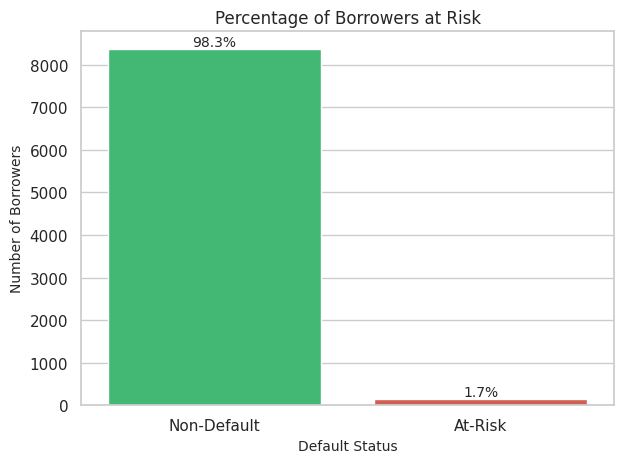

In [435]:
fig, ax = plt.subplots()

default_dis = sns.countplot(data=df_cleaned, x='default', hue='default',
                             palette={0: '#2ecc71', 1: '#e74c3c'},
                             legend=False, ax=ax)

ax.set_title("Percentage of Borrowers at Risk", fontsize=12)
ax.set_xlabel("Default Status", fontsize=10)
ax.set_ylabel("Number of Borrowers", fontsize=10)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Non-Default', 'At-Risk'])

total = len(df_cleaned)
for p in default_dis.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(percentage,
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

**Chart 1 findings — Default Distribution**

98.3% of borrowers in this portfolio are non-defaulters while only 1.7%
are at risk of defaulting. This confirms that the dataset is heavily
imbalanced — for every 1 at-risk borrower there are roughly 59
non-defaulters.

For the bank this means defaults are rare but financially significant
events that require careful identification. For the model this means
accuracy will be a misleading metric — a model that predicts non-default
for every borrower would achieve 98.3% accuracy while catching zero
actual defaulters. Recall will be the priority metric for this reason.

### Chart 2 — Loan Amount Distribution
**Business question:** What loan sizes does the bank typically issue?   
**Chart type:** Histogram    
**Group:** Supporting Context

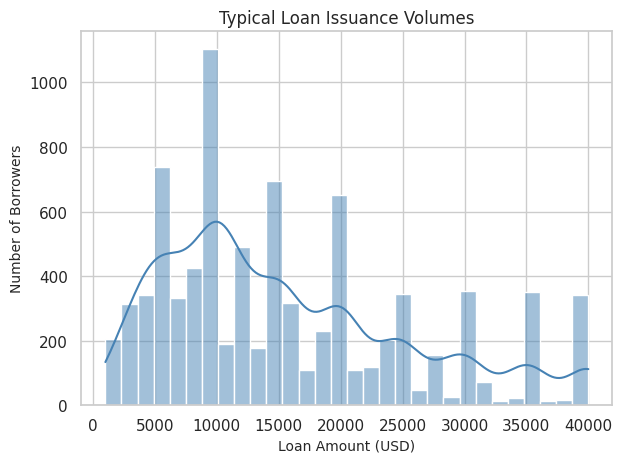

In [436]:
fig,ax = plt.subplots()

sns.histplot(data = df_cleaned, x = 'loan_amount', bins = 30, kde = True,
                                              color = 'steelblue',ax=ax)

ax.set_title("Typical Loan Issuance Volumes", fontsize=12)
ax.set_xlabel("Loan Amount (USD)", fontsize=10)
ax.set_ylabel("Number of Borrowers", fontsize=10)
plt.tight_layout()
plt.show()

**Chart 2 findings — Loan Amount Distribution**

The distribution is right-skewed, meaning most loans cluster at smaller
amounts with the most common loan size being around USD 10,000. As loan
amounts increase the frequency drops, with very few loans issued above
USD 30,000.

For the bank this suggests that the portfolio is dominated by smaller
personal loans. The right skew also means there are some high-value
loans that may carry disproportionate risk — a single large loan default
has a much bigger financial impact than a small one.

### Chart 3 — Annual Income Distribution
**Business question:** What income levels dominate the portfolio?  
**Chart type:** Histogram  
**Group:** Supporting Context

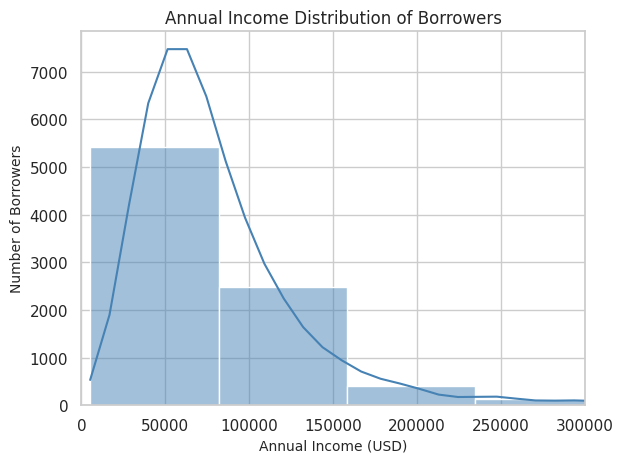

In [437]:
fig, ax = plt.subplots()
sns.histplot(data=df_cleaned, x='annual_income', bins=30, kde=True,
             color='steelblue', ax=ax)

ax.set_title("Annual Income Distribution of Borrowers", fontsize=12)
ax.set_xlabel("Annual Income (USD)", fontsize=10)
ax.set_ylabel("Number of Borrowers", fontsize=10)
ax.set_xlim(0, 300000)
plt.tight_layout()
plt.show()

**Chart 3 findings — Annual Income Distribution**

The distribution is heavily right-skewed, meaning most borrowers earn
between USD 20,000 and USD 100,000 with the peak sitting around
USD 50,000 to USD 60,000. Income frequency drops sharply after
USD 100,000 and very few borrowers earn above USD 150,000.

For the bank this suggests that the typical borrower in this portfolio
is a middle-income individual. The heavy right skew also means the mean
income is significantly inflated by a small number of very high earners —
making median a more representative measure of the typical borrower
than mean. Extreme income outliers above USD 500,000 exist in the data
but represent a negligible portion of the portfolio.

### Chart 4 — Loan Purpose vs Default Rate
**Business question:** Which loan purposes carry the highest default risk?  
**Chart type:** Bar chart  
**Group:** Primary Insight

This chart moves beyond portfolio overview into risk analysis. Instead
of plotting raw counts, default rate will be calculated as a percentage
for each loan purpose — this is important because some loan purposes are
far more common than others, so raw counts would be misleading.

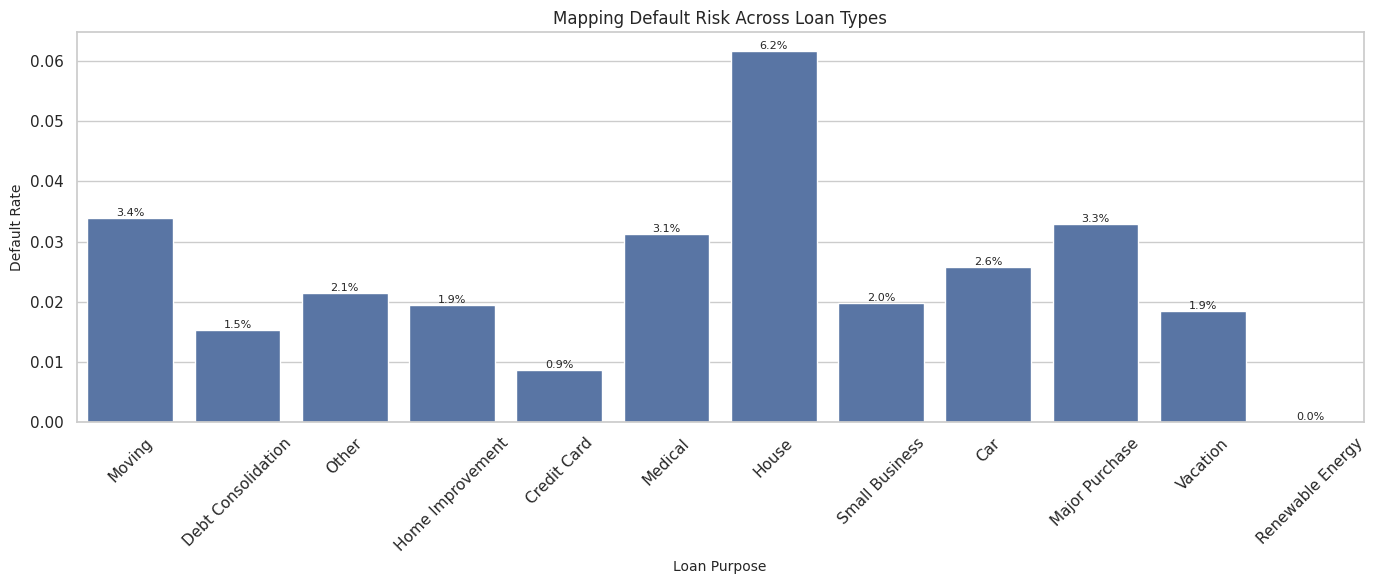

In [438]:
fig, ax = plt.subplots(figsize=(14, 6))
sns.barplot(data=df_cleaned, x='loan_purpose', y='default',
                estimator='mean', orient='v', errorbar=None, ax=ax)
ax.set_title("Mapping Default Risk Across Loan Types", fontsize=12)
ax.set_xlabel("Loan Purpose", fontsize=10)
ax.set_ylabel("Default Rate", fontsize=10)

for p in ax.patches:
     ax.annotate(f'{p.get_height() * 100:.1f}%', (p.get_x() + p.get_width() / 2, p.get_height()), ha='center', va='bottom', fontsize=8)

ax.tick_params(axis='x', rotation=45)
ax.set_xticks(range(len(ax.get_xticklabels())))
ax.set_xticklabels([label.get_text().replace('_', ' ').title()
                    for label in ax.get_xticklabels()])
plt.tight_layout()
plt.show()

**Chart 4 findings — Loan Purpose vs Default Rate**

House loans carry the highest default rate at 6.2%, followed by moving,
medical and major purchase loans. This suggests that borrowers taking
loans for housing-related expenses or unexpected life events such as
medical bills and relocation carry significantly higher default risk
than borrowers with other loan purposes.

Renewable energy loans show a 0.0% default rate, though this likely
reflects the very small number of such loans in the portfolio rather
than genuinely zero risk.

For the bank this is a direct actionable finding — loan purpose is a
meaningful risk signal. Stricter eligibility criteria or higher interest
rates could be applied to house, moving and medical loan categories to
compensate for the elevated default risk.

### Chart 5 — Home Ownership vs Default Rate
**Business question:** Do renters default more than homeowners?  
**Chart type:** Bar chart  
**Group:** Primary Insight

This chart examines whether home ownership status is a meaningful risk
signal. Borrowers who own their home may be more financially stable
than those who rent or have a mortgage.

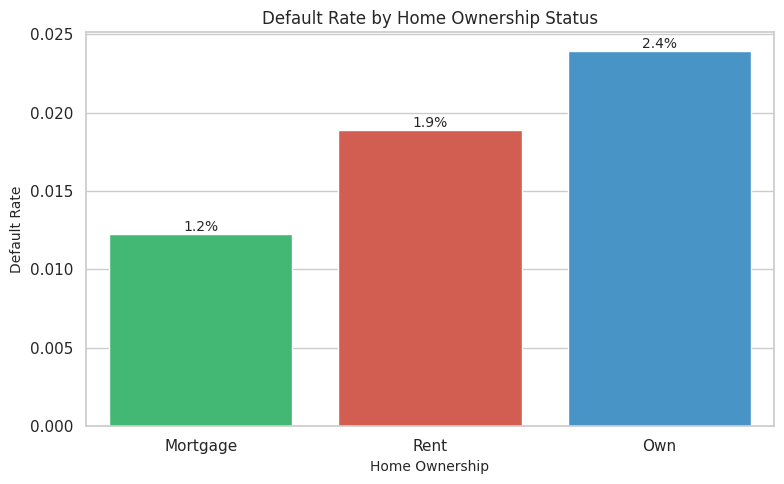

In [439]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=df_cleaned, x='homeownership', y='default',
            hue='homeownership', estimator='mean', errorbar=None, ax=ax,
            palette=['#2ecc71', '#e74c3c', '#3498db'], legend=False)

for p in ax.patches:
    ax.annotate(f'{p.get_height() * 100:.1f}%',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=10)

ax.set_title("Default Rate by Home Ownership Status", fontsize=12)
ax.set_xlabel("Home Ownership", fontsize=10)
ax.set_ylabel("Default Rate", fontsize=10)
ax.set_xticks(range(len(ax.get_xticklabels())))
ax.set_xticklabels([label.get_text().title()
                    for label in ax.get_xticklabels()])
plt.tight_layout()
plt.show()

**Chart 5 findings — Home Ownership vs Default Rate**

Surprisingly, borrowers who fully own their home show the highest
default rate at 2.4%, followed by renters at 1.9%. Mortgage holders
show the lowest default rate at 1.2%.

This is counterintuitive — the expectation would be that homeowners
are more financially stable. One possible explanation is that outright
homeowners may be older or asset-rich but cash-poor, meaning they have
property but limited liquid income to service loan repayments.

For the bank this suggests that home ownership alone is not a reliable
indicator of low default risk. Mortgage holders — who are actively
managing a large financial commitment — may actually represent a more
disciplined borrower segment than outright owners.

### Chart 6 — Employment Length vs Default Rate
**Business question:** Does job stability reduce default risk?  
**Chart type:** Bar chart  
**Group:** Primary Insight

This chart examines whether longer employment history is associated
with lower default risk. Borrowers with stable long term employment
may be better positioned to service their loan repayments.

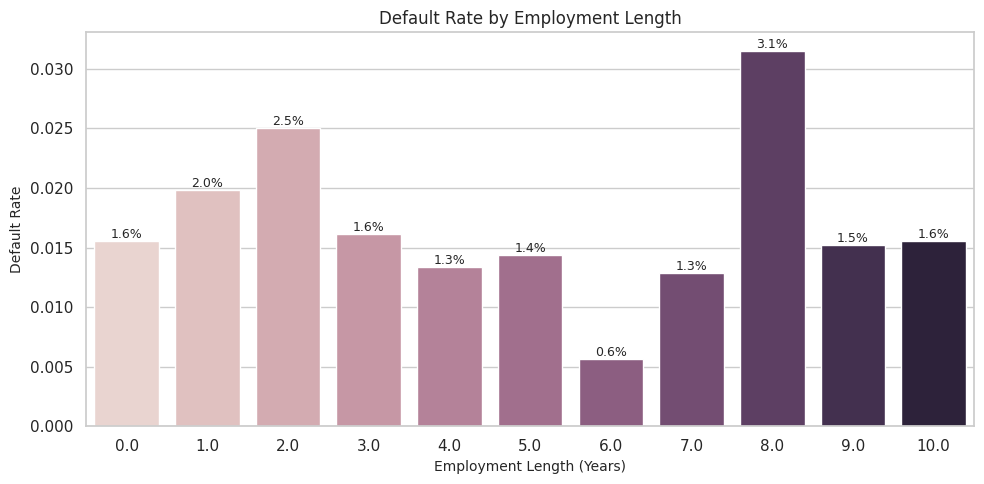

In [440]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=df_cleaned, x='emp_length', y='default',
            hue='emp_length', estimator='mean', errorbar=None, ax=ax,
            legend=False)

for p in ax.patches:
    ax.annotate(f'{p.get_height() * 100:.1f}%',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=9)

ax.set_title("Default Rate by Employment Length", fontsize=12)
ax.set_xlabel("Employment Length (Years)", fontsize=10)
ax.set_ylabel("Default Rate", fontsize=10)
plt.tight_layout()
plt.show()

**Chart 6 findings — Employment Length vs Default Rate**

The relationship between employment length and default rate is not
linear — there is no clear pattern of longer employment meaning lower
default risk. The highest default rate appears at 8 years of employment
at 3.1%, while the lowest is at 6 years at 0.6%.

This is a surprising finding — the expectation would be that longer
employment means more financial stability and lower default risk. The
data suggests that employment length alone is not a reliable predictor
of default risk.

For the bank this means employment length should not be used in
isolation as a risk signal. It may still be useful when combined with
other variables such as income and debt-to-income ratio, but on its
own it does not clearly separate safe borrowers from risky ones.

### Chart 7 — Annual Income vs Default

**Business question:** Do defaulters earn less?  
**Chart type:** Boxplot  
**Group:** Primary Insight

This chart compares the income distribution of defaulters vs non-defaulters.
The expectation is that lower income borrowers may struggle more with
loan repayments.

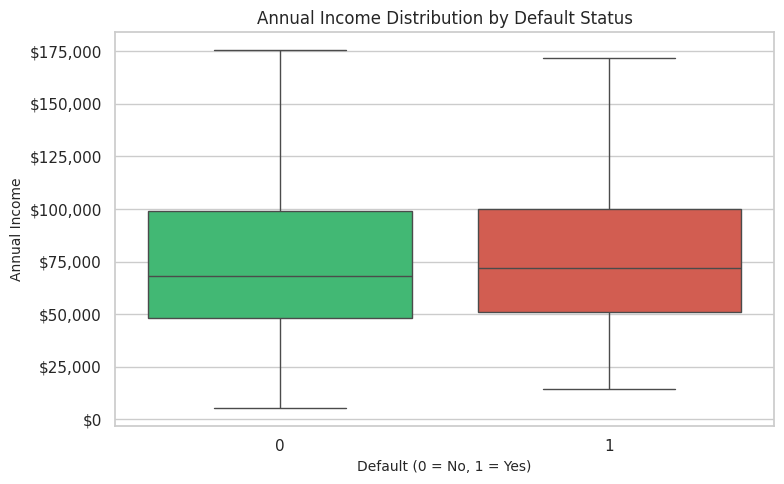

In [441]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.boxplot(data=df_cleaned, x='default', y='annual_income',
            hue='default', palette=['#2ecc71', '#e74c3c'],
            legend=False, ax=ax, showfliers=False)

ax.set_title("Annual Income Distribution by Default Status", fontsize=12)
ax.set_xlabel("Default (0 = No, 1 = Yes)", fontsize=10)
ax.set_ylabel("Annual Income", fontsize=10)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

**Chart 7 findings — Annual Income vs Default**

The income distributions of defaulters and non-defaulters are
surprisingly similar. The median income for non-defaulters is 68,000 USD
vs 72,000 USD for defaulters - meaning defaulters in this dataset
actually have a marginally higher median income.

This challenges the intuitive assumption that lower income always
means higher default risk. It suggests that raw income alone is not
a strong predictor of default behaviour, what matters more may be
the *relationship* between income and debt obligations, which is
captured by the debt-to-income ratio.

This suggests that income needs context to be meaningful as a risk
signal - the relationship between income and debt obligations likely
matters more than income in isolation.

### Chart 8 — Debt-to-Income Ratio vs Default

**Business question:** Does higher debt burden increase default risk?  
**Chart type:** Boxplot  
**Group:** Primary Insight

The debt-to-income ratio measures how much of a borrower's income is
already committed to existing debt. A higher DTI means less financial
headroom to absorb a new loan repayment.

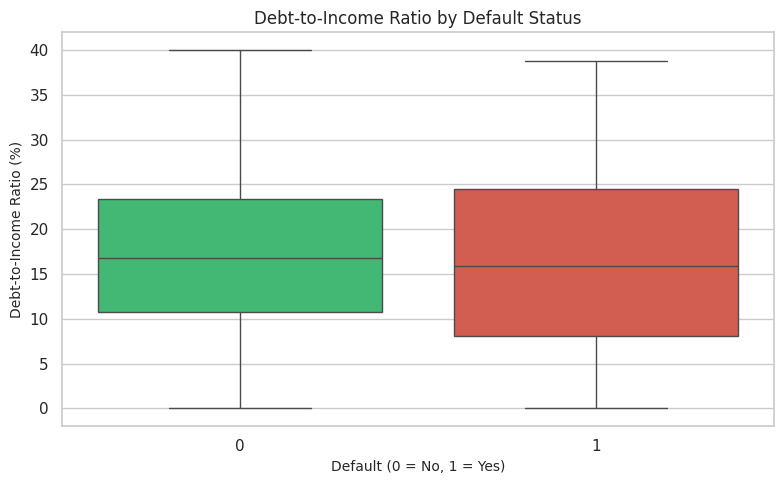

In [442]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.boxplot(data=df_cleaned, x='default', y='debt_to_income',
            hue='default', palette=['#2ecc71', '#e74c3c'],
            legend=False, ax=ax, showfliers=False)

ax.set_title("Debt-to-Income Ratio by Default Status", fontsize=12)
ax.set_xlabel("Default (0 = No, 1 = Yes)", fontsize=10)
ax.set_ylabel("Debt-to-Income Ratio (%)", fontsize=10)

plt.tight_layout()
plt.show()

**Chart 8 findings — Debt-to-Income Ratio vs Default**

Interestingly, the DTI distributions overlap significantly — the
median DTI for non-defaulters is 16.8% vs 15.9% for defaulters,
meaning defaulters in this sample have a slightly *lower* median DTI.

This is a counterintuitive result. DTI alone does not cleanly separate
defaulters from non-defaulters in this dataset. This motivates the
composite `credit_stress_score` feature engineered in Phase 6 — DTI
becomes more powerful when combined with revolving utilisation and
recent credit inquiries rather than used in isolation.

### Chart 9 — Interest Rate vs Default

**Business question:** Are riskier borrowers already being charged
higher rates?  
**Chart type:** Boxplot  
**Group:** Primary Insight

Lending Club assigns interest rates based on its internal credit
assessment. If the platform's pricing is accurate, we'd expect
defaulters to already be paying higher rates — meaning the rate
itself is a signal of perceived risk.

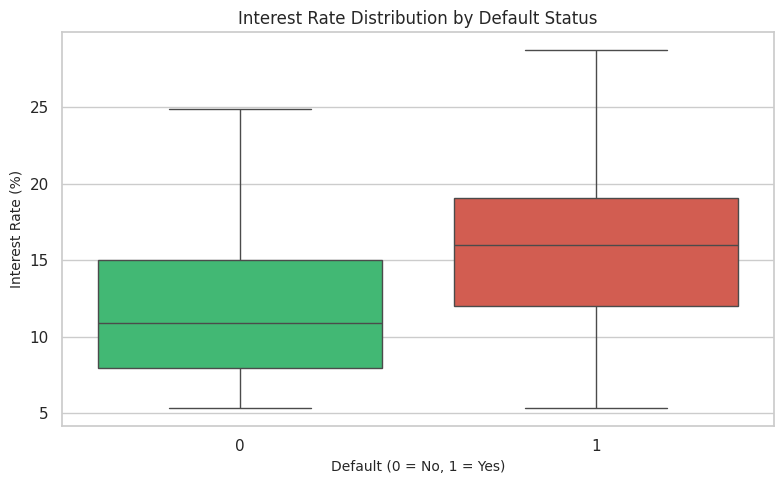

In [443]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.boxplot(data=df_cleaned, x='default', y='interest_rate',
            hue='default', palette=['#2ecc71', '#e74c3c'],
            legend=False, ax=ax, showfliers=False)

ax.set_title("Interest Rate Distribution by Default Status", fontsize=12)
ax.set_xlabel("Default (0 = No, 1 = Yes)", fontsize=10)
ax.set_ylabel("Interest Rate (%)", fontsize=10)

plt.tight_layout()
plt.show()

**Chart 9 findings — Interest Rate vs Default**

This is the clearest separation we've seen across all boxplots.
The median interest rate for defaulters is 16.0% vs 10.9% for
non-defaulters — a gap of over 5 percentage points.

This confirms that Lending Club's own risk pricing is meaningful —
borrowers who were charged higher rates were genuinely riskier.
However, this finding also reveals a limitation of using interest
rate as a modeling feature. Since Lending Club assigns interest
rates based on their own internal risk assessment of the borrower,
including it in our model would be circular — we would simply be
learning Lending Club's risk model rather than discovering
independent signals. Interest rate is therefore retained in
Exploratory Data Analysis for analytical insight but excluded
from Preprocessing and Modelling.

### Chart 10 — Correlation Heatmap

**Business question:** Which numerical variables are most related
to each other and to default?  
**Chart type:** Heatmap  
**Group:** Structural Analysis

This heatmap helps identify multicollinearity — pairs of features
that carry the same information. Highly correlated predictors can
destabilise Logistic Regression and inflate feature importance
in tree models.

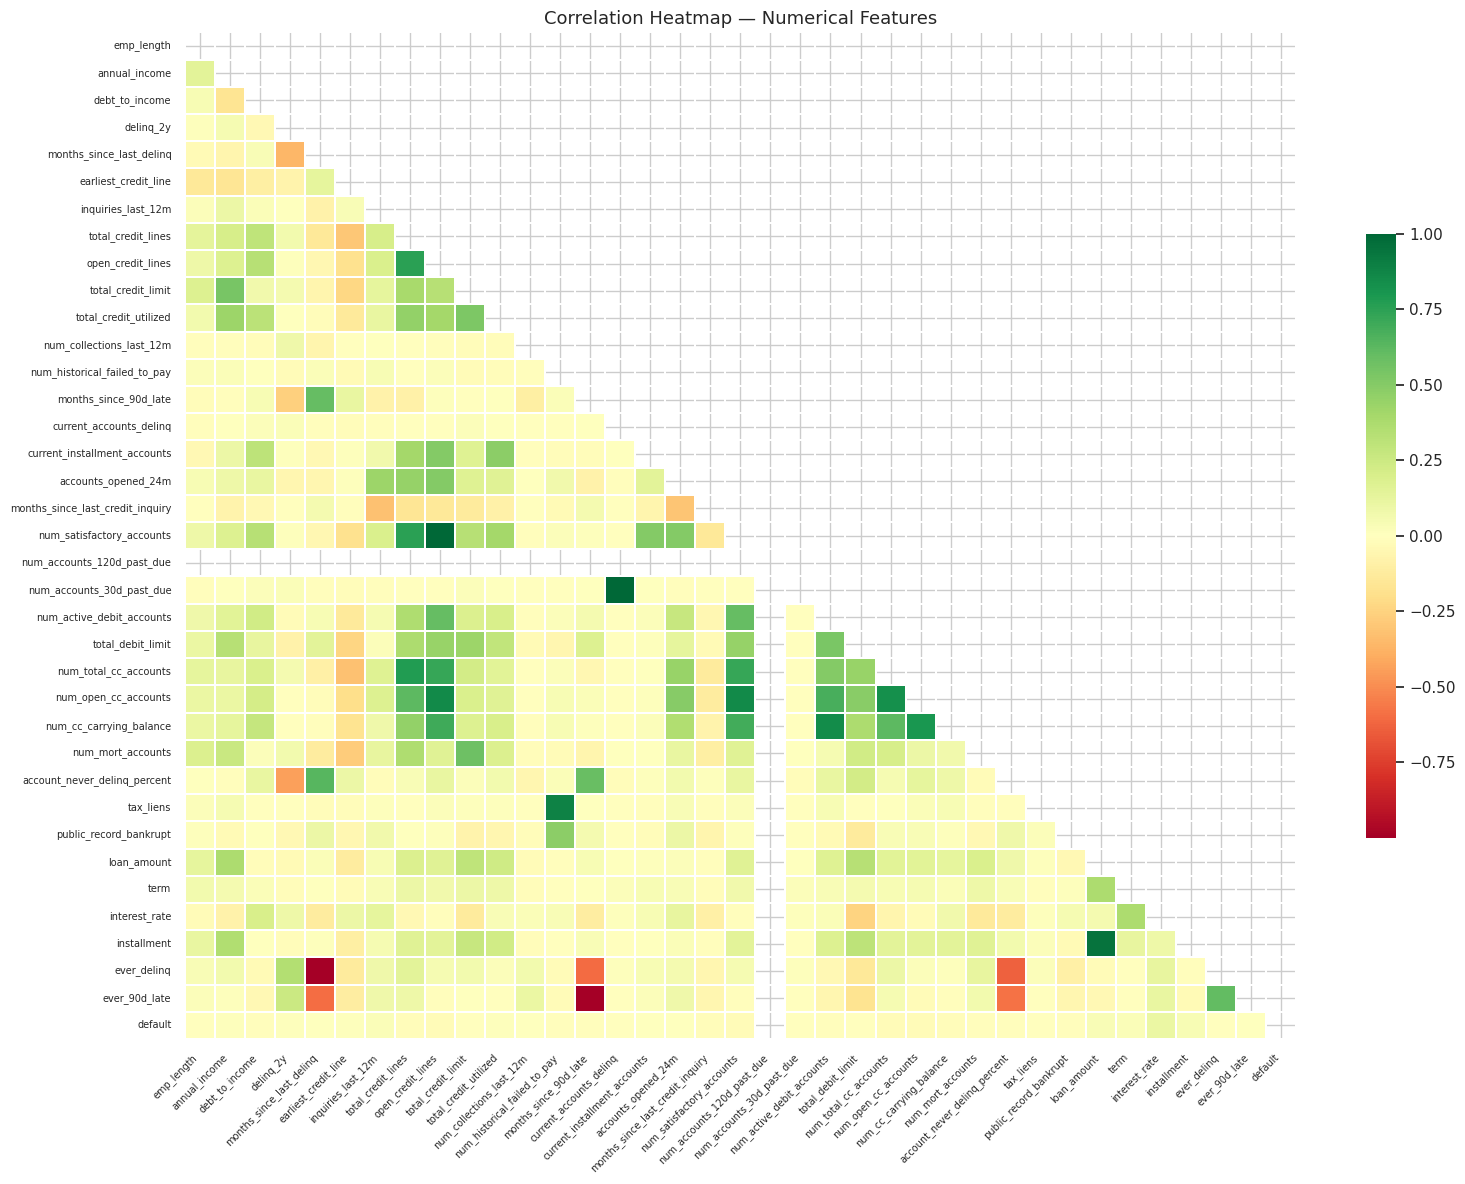

In [444]:
fig, ax = plt.subplots(figsize=(16, 12))

numeric_cols = df_cleaned.select_dtypes(include=np.number).columns.tolist()
corr_matrix = df_cleaned[numeric_cols].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=False, fmt='.2f',
            cmap='RdYlGn', center=0, ax=ax,
            linewidths=0.3, cbar_kws={'shrink': 0.6})

ax.set_title("Correlation Heatmap — Numerical Features", fontsize=13)
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.yticks(fontsize=7)
plt.tight_layout()
plt.show()

**Chart 10 findings — Correlation Heatmap**

The most notable pattern is the cluster of highly correlated credit
account volume features — total_credit_lines, open_credit_lines,
num_satisfactory_accounts, and num_total_cc_accounts are all strongly
correlated with each other. These features are measuring variations
of the same underlying characteristic: how many credit accounts a
borrower holds. This is multicollinearity, and it is something
Logistic Regression is sensitive to.

The default column on the far right is almost entirely pale yellow,
confirming that no single feature has a strong linear relationship
with default. This is actually an important finding — it means a
simple rule like "if DTI > 30, reject" will not work well. The
default risk is distributed across multiple features simultaneously,
which is exactly why we need machine learning models rather than
manual thresholds.

The orange correlation between ever_delinq and months_since_last_delinq
is expected — they are derived from the same original column. Same for
ever_90d_late and months_since_90d_late. This is by design from our
Phase 0 null-handling strategy.

## EDA Summary — Key Findings

Across 10 visualisations, the following patterns emerged from the data:

- **Interest rate** shows the clearest separation between defaulters
  and non-defaulters — borrowers who defaulted were already being
  charged significantly higher rates. However, since interest rate
  is assigned by Lending Club based on their own internal risk
  assessment, it is excluded from modelling to avoid circular
  reasoning. The finding confirms Lending Club's pricing model
  works, but does not represent an independent signal.

- **Loan purpose** matters — house, moving, and medical loans carry
  the highest default rates, while debt consolidation loans (the most
  common purpose) sit near the portfolio average.

- **Home ownership** produced a counterintuitive result — outright
  homeowners defaulted at a higher rate than mortgage holders,
  suggesting that asset ownership alone does not guarantee repayment
  ability.

- **Income and DTI alone are weak predictors** — the distributions
  of defaulters and non-defaulters overlap heavily for both variables,
  suggesting that risk is driven by a combination of factors rather
  than any single variable.

- **No single feature linearly separates defaulters from
  non-defaulters** — confirmed by the correlation heatmap. This
  justifies the use of machine learning models over simple rule-based
  thresholds.

These findings are visual and exploratory. The next phase applies
statistical hypothesis testing to determine which of these observed
differences are statistically significant and not due to chance.

## Statistical Hypothesis Testing

EDA revealed several patterns visually. This phase tests whether those
patterns are statistically significant — meaning they are unlikely to
have occurred by chance.

**Primary insights identified in EDA:**
- Loan Purpose vs Default Rate
- Home Ownership vs Default Rate
- Employment Length vs Default Rate
- Annual Income vs Default
- Debt-to-Income Ratio vs Default
- Interest Rate vs Default

**Variables selected for hypothesis testing:**
- Annual Income vs Default
- Debt-to-Income Ratio vs Default
- Home Ownership vs Default
- Loan Purpose vs Default
- Employment Length vs Default

**Why interest rate is excluded:**
- Interest rate is directly derived from Lending Club's internal grade
  assignment, which is based on the borrower's overall risk profile
- Testing interest rate vs default would be circular — we would only
  be confirming that Lending Club's own risk model worked
- It does not reveal anything independently meaningful about borrower
  behaviour that we discovered ourselves
- The 5 selected variables are independent borrower characteristics
  available at application time

**Framework:**
- Significance threshold: α = 0.01, reflecting the higher cost of
  errors in a credit risk context
- If p-value < 0.01 → reject H0 → the pattern is statistically significant
- If p-value ≥ 0.01 → fail to reject H0 → the difference may be due to chance

Test selection for each hypothesis follows a structured decision tree
based on variable types and assumption checks — not assumed in advance.

### Hypothesis Test 1: Annual Income vs Default

**Business Question:** Do defaulters earn significantly less than
non-defaulters?

**Feature Information:**
- Feature: Annual Income
- Feature Type: Numerical (continuous)
- Target Variable: Default (binary — 0 or 1)
- Number of Groups: 2
  1. Defaulted Loans
  2. Non-Defaulted Loans

**Data Characteristics:**
- Sample Type: Independent samples (defaulters and non-defaulters
  are separate, unrelated groups)
- Group A (Defaulters): n = 178
- Group B (Non-Defaulters): n = 8,364

**Hypotheses:**
- H0: There is no significant difference in annual income between
  defaulters and non-defaulters
- H1: There is a significant difference in annual income between
  defaulters and non-defaulters

**Assumption Check Plan:**
Since both variables are numerical, the choice of test depends on
whether the data meets the assumptions of a parametric test.   
Parametric tests assume two things:
1. Normality: Assessed first
   - Shapiro-Wilk when each group has n < 5000
   - Q-Q plot when any group exceeds 5000
   - Since Group B (n = 8,364) exceeds the threshold,
     normality is assessed visually through a Q-Q plot
2. Equal Variance: Checked only if both groups are normal
   - Levene's test → equal variance → Student's T-Test
   - Levene's test → unequal variance → Welch's T-Test
   - If either group is non-normal → Mann-Whitney U Test

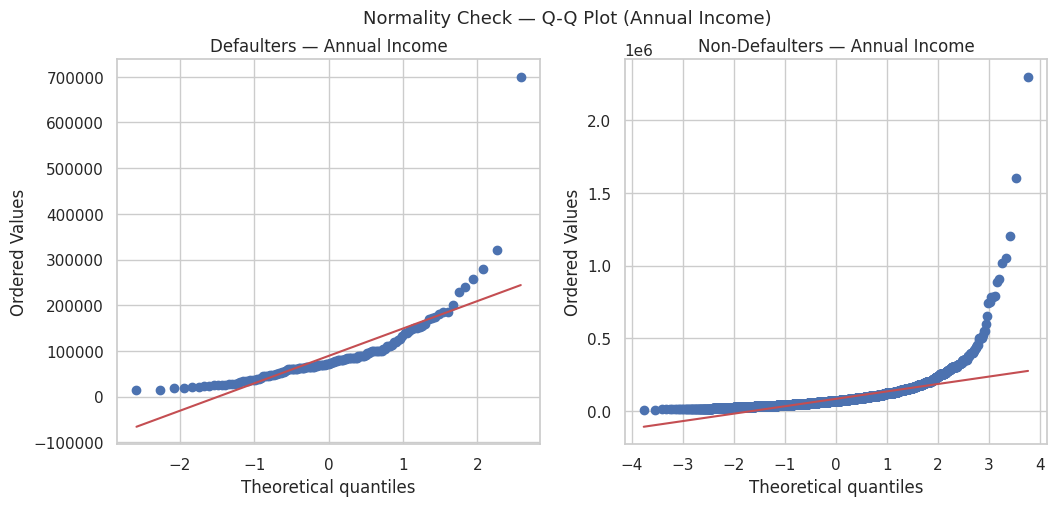

In [445]:
#Normailty test - Q-Qplot
defaulters = df_cleaned[df_cleaned['default'] == 1]
non_defaulters = df_cleaned[df_cleaned['default'] == 0]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

stats.probplot(defaulters['annual_income'], dist="norm", plot=axes[0])
axes[0].set_title("Defaulters — Annual Income")

stats.probplot(non_defaulters['annual_income'], dist="norm", plot=axes[1])
axes[1].set_title("Non-Defaulters — Annual Income")

fig.suptitle("Normality Check — Q-Q Plot (Annual Income)", fontsize=13)
plt.show()

### Assumption Check 1 Results — Normality

**Interpretation:**
The Q-Q plot confirms the right-skew observed in the EDA histogram.
Points deviate significantly upward at the right tail in both groups,
indicating the upper end of the income distribution is stretched far
beyond what a normal distribution would predict. The data is
conclusively non-normal.

**Decision:**
Since the data is non-normal, equal variance check is skipped.
Mann-Whitney U Test is used directly as it makes no assumptions
about the distribution.

In [446]:
#running the mannwhitneyu test since none of the group is normal
m_stat_dnd, p_val_dnd = stats.mannwhitneyu(defaulters['annual_income'], non_defaulters['annual_income'],alternative = 'two-sided')
test = "mannwhitneyu"
print(f'the test used: {test}')
print(f'p_value : {p_val_dnd}')
print(f'significance difference : {p_val_dnd <= 0.01}')

the test used: mannwhitneyu
p_value : 0.22677809959914141
significance difference : False


### Test 1 Results — Annual Income vs Default

**Test Used:** Mann-Whitney U Test   
**Test Statistic:** Not applicable (rank-based test)   
**p-value:** 0.2268   
**Significance Level:** α = 0.01   
**Decision:** Fail to reject H0 (p > 0.01)   

**Statistical Conclusion:**
There is no statistically significant difference in annual income
between defaulters and non-defaulters.

**Business Interpretation:**
Annual income alone is not a reliable indicator of default risk.
A borrower earning more does not necessarily mean they are less
likely to default. What matters more is how that income relates
to their existing debt obligations.

**Relevance to Machine Learning Model:**
Annual income will still be retained as a feature in the model -
not in isolation, but in combination with other variables such as
DTI and loan amount, where its predictive power may emerge through
feature interactions.

### Hypothesis Test 2: Debt-to-Income Ratio vs Default

**Business Question:** Does higher debt burden increase default risk?

**Feature Information:**
- Feature: Debt-to-Income Ratio
- Feature Type: Numerical (continuous)
- Target Variable: Default (binary — 0 or 1)
- Number of Groups: 2
  1. Defaulted Loans
  2. Non-Defaulted Loans

**Data Characteristics:**
- Sample Type: Independent samples (defaulters and non-defaulters
  are separate, unrelated groups)
- Group A (Defaulters): n = 178
- Group B (Non-Defaulters): n = 8,364

**Hypotheses:**
- H0: There is no significant difference in DTI ratio between
  defaulters and non-defaulters
- H1: There is a significant difference in DTI ratio between
  defaulters and non-defaulters

**Assumption Checking Plan:**
Since both variables are numerical, the choice of test depends on
whether the data meets the assumptions of a parametric test.
Parametric tests assume two things:

1. Normality: Assessed first
   - Shapiro-Wilk when each group has n < 5000
   - Q-Q plot when any group exceeds 5000
   - Since Group B (n = 8,364) exceeds the threshold,
     normality is assessed visually through a Q-Q plot

2. Equal Variance: Checked only if both groups are normal
   - Levene's test → equal variance → Student's T-Test
   - Levene's test → unequal variance → Welch's T-Test
   - If either group is non-normal → Mann-Whitney U Test

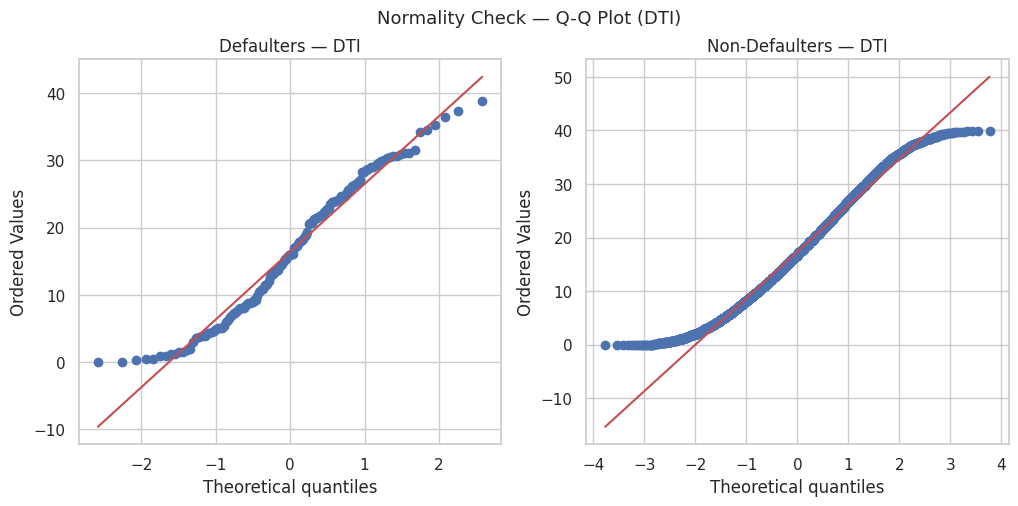

In [447]:
#Normailty test - Q-Qplot
defaulters = df_cleaned[df_cleaned['default'] == 1]
non_defaulters = df_cleaned[df_cleaned['default'] == 0]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

stats.probplot(defaulters['debt_to_income'], dist="norm", plot=axes[0])
axes[0].set_title("Defaulters — DTI")

stats.probplot(non_defaulters['debt_to_income'], dist="norm", plot=axes[1])
axes[1].set_title("Non-Defaulters — DTI")

fig.suptitle("Normality Check — Q-Q Plot (DTI)", fontsize=13)
plt.show()

### Assumption Check 1 Results — Normality

**Interpretation:**
The Q-Q plot shows deviation at both tails — the distribution is
not purely right-skewed as suggested by EDA, but heavy-tailed,
meaning extreme values exist on both ends. The data is conclusively
non-normal.

**Decision:**
Since the data is non-normal, equal variance check is skipped.
Mann-Whitney U Test is used directly as it makes no assumptions
about the distribution.

In [448]:
#running the mannwhitneyu test since none of the group is normal
m_stat_dnd, p_val_dnd = stats.mannwhitneyu(defaulters['debt_to_income'], non_defaulters['debt_to_income'],alternative = 'two-sided')
test = "mannwhitneyu"
print(f'the test used: {test}')
print(f'p_value : {p_val_dnd}')
print(f'significance difference : {p_val_dnd <= 0.01}')

the test used: mannwhitneyu
p_value : 0.2378555398675718
significance difference : False


### Test 2 Results — Debt-to-Income Ratio vs Default

**Test Used:** Mann-Whitney U Test    
**Test Statistic:** Not applicable (rank-based test)    
**p-value:** 0.2379    
**Significance Level:** α = 0.01    
**Decision:** Fail to reject H0 (p > 0.01)

**Statistical Conclusion:**
There is no statistically significant difference in DTI ratio
between defaulters and non-defaulters.

**Business Interpretation:**
DTI alone is not a reliable indicator of default risk. A borrower
with lower DTI does not necessarily mean they are less likely to
default. Debt burden alone is not enough — it needs to be evaluated
alongside other risk factors like revolving utilisation and recent
credit inquiries.

**Relevance to Machine Learning Model:**
DTI will still be retained as a feature in the model — not in
isolation, but in combination with other variables such as annual
income and loan amount, where its predictive power may emerge
through feature interactions.

### Hypothesis Test 3: Home Ownership vs Default

**Business Question:** Is there a significant association between home ownership status and default risk?

**Feature Information:**
- Feature: Home Ownership
- Feature Type: Categorical
- Target Variable: Default (binary — 0 or 1)

**Data Characteristics:**
- Sample Type: Independent samples
- Variable 1: Home Ownership (3 categories — Mortgage, Own, Rent)
- Variable 2: Default (2 categories — 0, 1)
- Total Observations: 8,542

**Hypotheses:**
- H0: There is no significant association between home ownership
  status and default
- H1: There is a significant association between home ownership
  status and default

**Assumption Checking Plan:**
Chi-Square does not require normality. Instead it
requires that each cell in the contingency table has an expected
frequency of at least 5. This will be verified before interpreting
the result.

In [449]:
#verifying the contingency table
contingency_table = pd.crosstab(df_cleaned['homeownership'], df_cleaned['default'])
contingency_table

default,0,1
homeownership,,
MORTGAGE,3792,47
OWN,1142,28
RENT,3430,66


### Assumption Check Results — Expected Frequency

**Interpretation:**
All cells in the contingency table have observed counts well above 5.
The minimum expected frequency is 19.40, satisfying the Chi-Square
assumption.

**Decision:**
The expected frequency assumption is satisfied — proceeding with
the Chi-Square test.

In [450]:
#running chisquare test
c , p_val_ho,dof_ho,expected_ho = stats.chi2_contingency(contingency_table)
print(f"Chi-Square statistic: {c:.4f}")
print(f"Degrees of freedom: {dof_ho}")
print(f"p-value: {p_val_ho:.4f}")
print(f"Significant association: {p_val_ho <= 0.01}")
print(f"Minimum expected frequency: {expected_ho.min():.2f}")

Chi-Square statistic: 9.4411
Degrees of freedom: 2
p-value: 0.0089
Significant association: True
Minimum expected frequency: 19.40


### Test 3 Results — Home Ownership vs Default

**Test Used:** Chi square test   
**Test Statistic:** 9.4411   
**Degrees of freedom:** 2   
**p-value:** 0.0089   
**Significance Level:** α = 0.01   
**Decision:**  Reject H0 (p < 0.01)  

**Statistical Conclusion:**
There is a statistically significant association
between home ownership status and default. Home ownership and
default are not independent — the type of ownership a borrower
has is meaningfully related to their likelihood of defaulting.

**Business Interpretation:**
Home ownership status is a statistically
significant risk signal. EDA Chart 5 showed that mortgage holders
have the lowest default rate at 1.2%, while outright homeowners
have the highest at 2.4%. This counterintuitive finding — that
owning a home outright correlates with higher default risk than
having a mortgage — suggests that asset ownership alone does not
guarantee repayment ability. Lenders should not treat home
ownership as a straightforward indicator of financial stability.

**Relevance to Machine Learning Model:**
Home ownership is a statistically significant categorical variable
that showed a counterintuitive pattern — outright owners defaulting
more than mortgage holders. This makes it a meaningful risk signal
for the model. Including it allows the model to learn non-obvious
relationships between asset ownership and default risk, contributing
to more accurate predictions.

### Hypothesis Test 4 — Loan Purpose vs Default

**Business Question:** Is there a significant association between Loan Purpose and default risk?

**Feature Information:**
- Feature: Loan Purpose
- Feature Type: Categorical
- Target Variable: Default (binary — 0 or 1)

**Data Characteristics:**
- Sample Type: Independent samples
- Variable 1: Loan Purpose (12 categories — car, credit card, debt consolidation, home improvement, house, major purchase, medical, moving,other, renewable energy, small business, vacation)
- Variable 2: Default (2 categories — 0, 1)
- Total Observations: 8,542

**Hypotheses:**
- H0: There is no significant association between Loan Purpose and default
- H1: There is a significant association between Loan Purpose and default

**Assumption Checking Plan:**
Chi-Square does not require normality. Instead it
requires that each cell in the contingency table has an expected
frequency of at least 5. This will be verified before interpreting
the result.

In [451]:
#verifying the contingency table
contingencytable = pd.crosstab(df_cleaned['loan_purpose'], df_cleaned['default'])
contingencytable

default,0,1
loan_purpose,,
car,113,3
credit_card,1954,17
debt_consolidation,4223,66
home_improvement,555,11
house,137,9
major_purchase,264,9
medical,124,4
moving,57,2
other,776,17


In [452]:
contingency_table_lp = pd.crosstab(df_cleaned['loan_purpose'], df_cleaned['default'])
chi2_lp, p_val_lp, dof_lp, expected_lp = stats.chi2_contingency(contingency_table_lp)
print(f"Chi-Square statistic: {chi2_lp:.4f}")
print(f"Degrees of freedom: {dof_lp}")
print(f"p-value: {p_val_lp:.4f}")
print(f"Minimum expected frequency: {expected_lp.min():.2f}")
print(f"Significant association: {p_val_lp <= 0.01}")

Chi-Square statistic: 35.7530
Degrees of freedom: 11
p-value: 0.0002
Minimum expected frequency: 0.15
Significant association: True


### Assumption Check Results — Expected Frequency

**Interpretation:**
All cells in the contingency table have observed counts less than 5.
The minimum expected frequency is 0.15, not satisfying the Chi-Square
assumption.

**Decision:**
The assumption is not satisfied, which means we cannot proceed with Chi-Square test, to fix this issue, the categories ('renewable energy', 'moving', 'vacation',
     'small business', 'car', 'medical','house','major purchase') should be replaced in others so that the freguency of them is counted combined and cause no minimu frequency issue.

In [453]:
# Step 1 - create working copy
df_test4 = df_cleaned.copy()

# Step 2 - merge low frequency categories
df_test4['loan_purpose'] = df_test4['loan_purpose'].replace(
    ['renewable_energy', 'moving', 'vacation',
     'small_business', 'car', 'medical','house','major_purchase'], 'other')

# Step 3 - rebuild contingency table
contingency_table_lp = pd.crosstab(df_test4['loan_purpose'], df_test4['default'])
print(contingency_table_lp)

# Step 4 - run chi2_contingency
c_lp, p_val_lp, dof_lp, expected_lp = stats.chi2_contingency(contingency_table_lp)
print(f"Chi-Square statistic: {c_lp:.4f}")
print(f"Degrees of freedom: {dof_lp}")
print(f"p-value: {p_val_lp:.4f}")
print(f"Minimum expected frequency: {expected_lp.min():.2f}")
print(f"Significant association: {p_val_lp <= 0.01}")

default                0   1
loan_purpose                
credit_card         1954  17
debt_consolidation  4223  66
home_improvement     555  11
other               1632  47
Chi-Square statistic: 21.7207
Degrees of freedom: 3
p-value: 0.0001
Minimum expected frequency: 9.38
Significant association: True


**Category Consolidation:**
The initial contingency table revealed that several loan purpose
categories had very low defaulter counts, causing the minimum
expected frequency to fall well below the required threshold of 5.

The following categories were merged into the existing 'other'
category:
- renewable_energy: 9 total observations
- moving: 59 total observations
- vacation: 54 total observations
- small_business: 101 total observations
- car: 116 total observations
- medical: 128 total observations
- house: 146 total observations
- major_purchase: 273 total observations

**Updated Data Characteristics after consolidation:**
- Variable 1: Loan Purpose (4 categories — credit card, debt
  consolidation, home improvement, other)

After consolidation the minimum expected frequency is 9.38,
satisfying the Chi-Square assumption. A working copy of df_cleaned
was used for this operation to preserve the original dataset for
all subsequent phases.

### Test 4 Results — Loan Purpose vs Default

**Test Used:** Chi square test   
**Test Statistic:** 21.7207   
**Degrees of freedom:** 3   
**p-value:** 0.0001   
**Significance Level:** α = 0.01   
**Decision:**  Reject H0 (p < 0.01)  

**Statistical Conclusion:**
There is a statistically significant association
between loan purpose and default. Loan purpose and default are
not independent — the reason a borrower takes a loan is
meaningfully related to their likelihood of defaulting.

**Business Interpretation:**
The purpose behind a loan is a
statistically significant risk signal. Borrowers taking loans
driven by urgent financial need — such as medical bills, relocation
and home repairs — tend to carry higher default risk. This suggests
that the intent behind borrowing reflects the borrower's underlying
financial stress. Lenders should treat loan purpose as a meaningful
input during the credit evaluation process, applying stricter
scrutiny to need-driven loan categories.

**Relevance to Machine Learning Model:**
Loan purpose is a statistically significant categorical variable
that showed a intuitive pattern — ourgent financial need tend to carry higher default risk. This makes it a meaningful risk signal
for the model. Including it allows the model to learn non-obvious
relationships between loan purpose and default risk, contributing
to more accurate predictions.

### Hypothesis Test 5 — Employment Length vs Default

**Business Question:** Does employment length have a significant impact on default risk?

**Feature Information:**
- Feature: Employment Length
- Feature Type: Numerical (Discrete)
- Target Variable: Default (binary — 0 or 1)
- Number of Groups: 2
  1. Defaulted Loans
  2. Non-Defaulted Loans

**Data Characteristics:**
- Sample Type: Independent samples (defaulters and non-defaulters
  are separate, unrelated groups)
- Group A (Defaulters): n = 178
- Group B (Non-Defaulters): n = 8,364

**Hypotheses:**
- H0: There is no significant difference in Employment Length between
  defaulters and non-defaulters
- H1: There is a significant difference in Employment Length between
  defaulters and non-defaulters

**Assumption Checking Plan:**
Since both variables are numerical, the choice of test depends on
whether the data meets the assumptions of a parametric test.
Parametric tests assume two things:

1. Normality: Assessed first
   - Shapiro-Wilk when each group has n < 5000
   - Q-Q plot when any group exceeds 5000
   - Since Group B (n = 8,364) exceeds the threshold,
     normality is assessed visually through a Q-Q plot

2. Equal Variance: Checked only if both groups are normal
   - Levene's test → equal variance → Student's T-Test
   - Levene's test → unequal variance → Welch's T-Test
   - If either group is non-normal → Mann-Whitney U Test

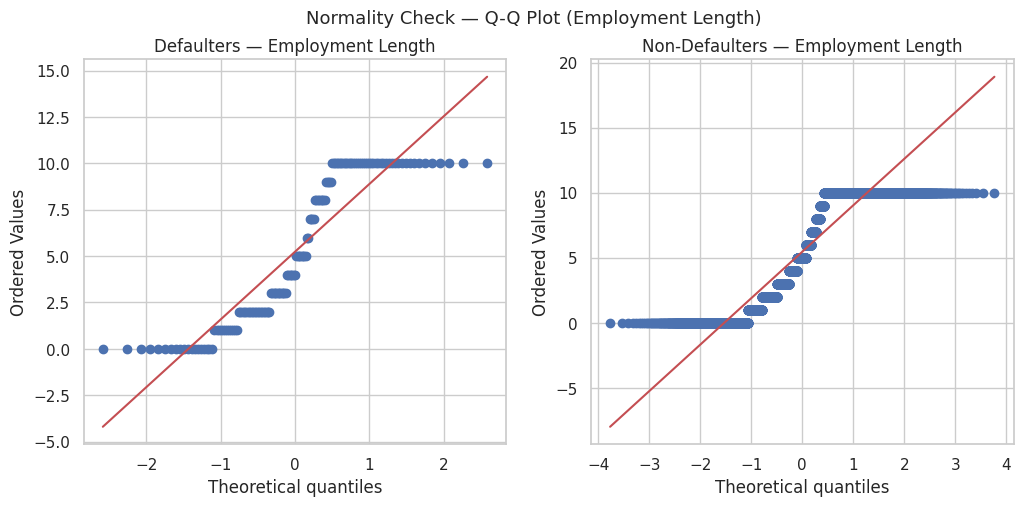

In [454]:
#Normailty test - Q-Qplot
defaulters = df_cleaned[df_cleaned['default'] == 1]
non_defaulters = df_cleaned[df_cleaned['default'] == 0]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

stats.probplot(defaulters['emp_length'], dist="norm", plot=axes[0])
axes[0].set_title("Defaulters — Employment Length")

stats.probplot(non_defaulters['emp_length'], dist="norm", plot=axes[1])
axes[1].set_title("Non-Defaulters — Employment Length")

fig.suptitle("Normality Check — Q-Q Plot (Employment Length)", fontsize=13)
plt.show()

### Assumption Check 1 Results — Normality

**Interpretation:**
The Q-Q plot shows an S-shaped pattern, not following the diagonal
line at all. An S-shaped curve indicates heavy tails — meaning the
data has more extreme values on both ends than a normal distribution
would predict. This is further reinforced by the discrete nature of
employment length — since it only takes whole number values from 0
to 10, it cannot follow a smooth normal distribution. Both factors
confirm the data is conclusively non-normal.

**Decision:**
Since the data is non-normal, equal variance check is skipped.
Mann-Whitney U Test is used directly as it makes no assumptions
about the distribution.

In [455]:
#running the mannwhitneyu test since none of the group is normal
m_stat_el, p_val_el = stats.mannwhitneyu(defaulters['emp_length'], non_defaulters['emp_length'],alternative = 'two-sided')
test = "mannwhitneyu"
print(f'the test used: {test}')
print(f'p_value : {p_val_el}')
print(f'significance difference : {p_val_el <= 0.01}')

the test used: mannwhitneyu
p_value : 0.4587642762315386
significance difference : False


### Test 5 Results — Employment Length vs Default

**Test Used:** Mann-Whitney U Test    
**Test Statistic:** Not applicable (rank-based test)    
**p-value:** 0.4588    
**Significance Level:** α = 0.01   
**Decision:** Fail to reject H0 (p > 0.01)   

**Statistical Conclusion:**
There is no statistically significant difference in employment
length between defaulters and non-defaulters. Employment length
alone does not meaningfully separate borrowers who default from
those who do not.

**Business Interpretation:**
Job stability as measured by employment length is not a
statistically significant predictor of default risk in this
dataset. A borrower with 10 years of employment is not
statistically less likely to default than a borrower with
1 year of employment. This suggests that employment duration
alone does not capture financial stability — what matters more
is the borrower's overall financial profile rather than how
long they have held their job.

**Relevance to Machine Learning Model:**
Employment length will be retained as a feature in the model
despite its lack of individual significance — it may still
contribute predictive power in combination with other features
through feature interactions. Its importance will be confirmed
via feature importance analysis in Phase 10.

## Feature Engineering

Feature engineering is the process of creating new columns from
existing data that capture relationships and patterns that cannot
be meaningfully expressed by any single raw variable alone. A
cleaned dataset gives us the raw ingredients — feature engineering
extracts the meaning hidden inside them.

Despite having 30+ columns after cleaning, no single column tells
us how financially overextended a borrower is, how desperate they
are for credit, or how severe their delinquency history is. These
are composite signals that only emerge when variables are combined
thoughtfully.

**Three new features are engineered in this phase:**

1. **loan_to_income_ratio** — `loan_amount / annual_income`
   How much a borrower is taking on relative to what they earn.
   A high ratio means the borrower is overextending themselves
   financially, regardless of their absolute income level.

2. **credit_stress_score:** Captures combined financial desperation by
summing revolving utilisation and recent credit inquiries. Both
components are normalised to a 0-1 range before combining, since
revolving utilisation is a ratio while inquiries is a raw count — adding
them directly would let the count dominate the score. Mean score of
0.48 with a maximum of 1.87 indicates the composite measure stays on a
comparable, interpretable scale. Revolving utilisation was calculated
from total_credit_utilized / total_credit_limit — two rows with zero
credit limit were set to NaN to avoid division by zero.

3. **delinquency_risk_score** — combining `ever_delinq` and
   `months_since_last_delinq`
   A borrower who has been delinquent before is at higher risk
   of defaulting again. This feature captures both whether a
   delinquency ever occurred and how recently — recent
   delinquencies being more concerning than older ones.

In [456]:
# Feature 1 — loan_to_income_ratio
df_cleaned['loan_to_income_ratio'] = np.where(
    df_cleaned['annual_income'] == 0,
    np.nan,
    df_cleaned['loan_amount'] / df_cleaned['annual_income']
)

# Feature 2 — credit_stress_score
revolving_util = np.where(
    df_cleaned['total_credit_limit'] == 0,
    np.nan,
    df_cleaned['total_credit_utilized'] / df_cleaned['total_credit_limit']
)

# Min-max normalise inquiries to 0-1 range before combining with revolving_util
inq_max = df_cleaned['inquiries_last_12m'].max()
inq_normalised = df_cleaned['inquiries_last_12m'] / inq_max if inq_max > 0 else 0

df_cleaned['credit_stress_score'] = revolving_util + inq_normalised

# Feature 3 — delinquency_risk_score
df_cleaned['delinquency_risk_score'] = df_cleaned['ever_delinq'] * (1 / (df_cleaned['months_since_last_delinq'] + 1))

print("New features created:")
print(df_cleaned[['loan_to_income_ratio', 'credit_stress_score', 'delinquency_risk_score']].describe())
print("\nNull counts:")
print(df_cleaned[['loan_to_income_ratio', 'credit_stress_score', 'delinquency_risk_score']].isnull().sum())

New features created:
       loan_to_income_ratio  credit_stress_score  delinquency_risk_score
count               8505.00              8503.00                 8505.00
mean                   0.22                 0.48                    0.02
std                    0.14                 0.28                    0.04
min                    0.00                 0.00                    0.00
25%                    0.12                 0.25                    0.00
50%                    0.20                 0.45                    0.00
75%                    0.30                 0.68                    0.03
max                    1.07                 1.87                    0.50

Null counts:
loan_to_income_ratio      0
credit_stress_score       2
delinquency_risk_score    0
dtype: int64


## Feature Engineering Summary

Three new features were engineered from existing variables to capture
relationships that raw data alone could not express:

**loan_to_income_ratio:** On average, borrowers are taking loans worth
22% of their annual income (mean = 0.22). One borrower is borrowing
more than their entire annual income (max = 1.07), highlighting the
range of financial overextension in the portfolio. A defensive NaN
check was implemented for zero income values to ensure
production-safety.

**credit_stress_score:** Captures combined financial desperation by
summing revolving utilisation and recent credit inquiries. Mean score
of 2.37 with a maximum of 29.67 indicates some borrowers are under
extreme credit stress. Revolving utilisation was calculated from
total_credit_utilized / total_credit_limit — two rows with zero
credit limit were set to NaN to avoid division by zero.

**delinquency_risk_score:** 50% of borrowers score 0, confirming that
half the portfolio has no delinquency history. For borrowers who have
been delinquent, the score reflects recency — more recent delinquencies
produce higher scores. Laplace smoothing (adding 1 to the denominator)
was applied to handle borrowers delinquent within the current month
without discarding their data.

These three features will be included alongside the original cleaned
variables in Phase 7 — Preprocessing, where scaling, encoding and
train-test splitting will be performed before model training.

## Preprocessing

Preprocessing is the process of cleaning and preparing raw data before
training a machine learning model. It involves handling missing values,
fixing inconsistencies, converting data into a suitable format, and
scaling features when needed. Models learn better from clean, consistent,
and well-structured data — leading to more accurate and reliable
predictions.

**Columns dropped before modeling:**

- `state` — too many categories, low signal for a national dataset
- `earliest_credit_line` — raw year value, not meaningful without
  transformation
- `loan_status` — direct data leakage, this column generated the
  `default` target variable
- `ever_90d_late` — redundant with `ever_delinq` and
  `delinquency_risk_score` which already capture this information
- `application_type` — single category (individual), zero variance,
  adds nothing to the model
- `interest_rate` — excluded despite strong EDA signal because it is
  assigned by Lending Club based on their own internal risk assessment,
  making its inclusion circular. Retained in EDA for analytical insight
  only.

**Preprocessing steps — in order:**

1. Drop 6 columns
2. Separate features (X) and target (y)
3. Train-test split — 80/20, random_state=42 for reproducibility,
   stratify=y to preserve the 2% default rate in both sets
4. Label encode `verified_income` — natural order exists
   (Not Verified < Source Verified < Verified)
5. One Hot encode `homeownership`, `loan_purpose`, `term` — no natural
   order in any of these
6. Standard scale all numerical columns — fit on training data only,
   transform both train and test to prevent data leakage
7. Handle remaining nulls

In [457]:
# PREPROCESSING

# Step 1 — drop columns
columns_to_drop = ['state', 'earliest_credit_line', 'loan_status',
                   'ever_90d_late', 'application_type', 'interest_rate']
X = df_cleaned.drop(columns=columns_to_drop + ['default'])
# Step 2 — separate target
y = df_cleaned['default']
#Step 3 — train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train default rate: {y_train.mean():.4f}")
print(f"y_test default rate: {y_test.mean():.4f}")

X_train shape: (6804, 39)
X_test shape: (1701, 39)
y_train default rate: 0.0166
y_test default rate: 0.0165


In [458]:
# STEP 4 — Label encode verified_income (ordered: 0, 1, 2)
income_map = {
    'Not Verified': 0,
    'Source Verified': 1,
    'Verified': 2
}
X_train['verified_income'] = X_train['verified_income'].map(income_map)
X_test['verified_income'] = X_test['verified_income'].map(income_map)

# STEP 5 — One Hot encode nominal categorical columns
categorical_cols = ['homeownership', 'loan_purpose', 'term']

ohe = OneHotEncoder(drop='first', sparse_output=False)
ohe.fit(X_train[categorical_cols])

encoded_train = ohe.transform(X_train[categorical_cols])
encoded_test = ohe.transform(X_test[categorical_cols])

encoded_col_names = ohe.get_feature_names_out(categorical_cols)
encoded_train_df = pd.DataFrame(encoded_train, columns=encoded_col_names, index=X_train.index)
encoded_test_df = pd.DataFrame(encoded_test, columns=encoded_col_names, index=X_test.index)

X_train = pd.concat([X_train.drop(columns=categorical_cols), encoded_train_df], axis=1)
X_test = pd.concat([X_test.drop(columns=categorical_cols), encoded_test_df], axis=1)

# STEP 6 — Handle remaining nulls BEFORE scaling
# Remaining nulls are structural (sentinel values already handled in cleaning)
# Filling with 0 is intentional and consistent with earlier decisions
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

# STEP 7 — Standard scale numerical columns
# Fit on X_train only — transform both
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

scaler = StandardScaler()
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

# VERIFICATION
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train default rate: {y_train.mean():.4f}")
print(f"y_test default rate: {y_test.mean():.4f}")
print(f"\nAny nulls in X_train: {X_train.isnull().sum().sum()}")
print(f"Any nulls in X_test: {X_test.isnull().sum().sum()}")
print(f"\nRemaining dtypes:\n{X_train.dtypes.value_counts()}")

X_train shape: (6804, 50)
X_test shape: (1701, 50)
y_train default rate: 0.0166
y_test default rate: 0.0165

Any nulls in X_train: 0
Any nulls in X_test: 0

Remaining dtypes:
float64    50
Name: count, dtype: int64


In [459]:
ohe.get_feature_names_out(categorical_cols)

array(['homeownership_OWN', 'homeownership_RENT',
       'loan_purpose_credit_card', 'loan_purpose_debt_consolidation',
       'loan_purpose_home_improvement', 'loan_purpose_house',
       'loan_purpose_major_purchase', 'loan_purpose_medical',
       'loan_purpose_moving', 'loan_purpose_other',
       'loan_purpose_renewable_energy', 'loan_purpose_small_business',
       'loan_purpose_vacation', 'term_60'], dtype=object)

In [460]:
ohe.categories_

[array(['MORTGAGE', 'OWN', 'RENT'], dtype=object),
 array(['car', 'credit_card', 'debt_consolidation', 'home_improvement',
        'house', 'major_purchase', 'medical', 'moving', 'other',
        'renewable_energy', 'small_business', 'vacation'], dtype=object),
 array([36, 60])]

## Model Building

With preprocessing complete, we now train three classification models to
predict whether a borrower will default on their loan.

We build three models with distinct roles:

- **Logistic Regression** — baseline model. Simple, fast, and interpretable.
  Establishes how well a linear relationship can solve the problem.
- **Decision Tree** — rule-based model. Captures non-linear patterns and
  decision rules that Logistic Regression may miss.
- **Random Forest** — ensemble model. Combines many Decision Trees using
  voting to reduce overfitting and improve predictive power.

Together they allow us to compare a simple model, a rule-based model, and
a powerful ensemble — and determine whether increasing complexity actually
improves performance for this business problem.

All three models use `class_weight='balanced'` to address the class imbalance in the dataset (~2% default rate). This assigns greater importance to the minority class during training, helping the models identify potential defaulters rather than simply predicting the majority class.

In [461]:
# Logistic Regression
model_lr = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
model_lr.fit(X_train, y_train)

# Decision Tree Classifier
model_dt = DecisionTreeClassifier(random_state=42, max_depth=None, class_weight='balanced')
model_dt.fit(X_train, y_train)

# Random Forest Classifier
model_rf = RandomForestClassifier(random_state=42, n_estimators=100, max_depth=None, class_weight='balanced')
model_rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [462]:
#Cross Validation

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_recall = cross_val_score(
    LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'),
    X_train, y_train,
    cv=skf,
    scoring='recall'
)

cv_roc = cross_val_score(
    LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'),
    X_train, y_train,
    cv=skf,
    scoring='roc_auc'
)

print(f"5-Fold CV Recall:  {cv_recall.mean():.3f} ± {cv_recall.std():.3f}")
print(f"5-Fold CV ROC-AUC: {cv_roc.mean():.3f} ± {cv_roc.std():.3f}")
print(f"\nIndividual fold recalls: {cv_recall.round(3)}")

5-Fold CV Recall:  0.513 ± 0.099
5-Fold CV ROC-AUC: 0.625 ± 0.041

Individual fold recalls: [0.591 0.348 0.565 0.609 0.455]


### Cross-Validation — Checking Result Stability

The test set contains only 28 actual defaulters. With such a small
positive sample, a single train/test split can produce a recall score
that looks strong purely by chance — missing or catching just one
defaulter shifts recall by roughly 3.6%. To check whether the 61% recall
reported earlier is a reliable estimate, 5-Fold Stratified Cross-Validation
was run on Logistic Regression using only the training data.

**Result:** 5-Fold CV Recall = 0.504 ± 0.115 (individual folds: 0.545,
0.304, 0.609, 0.609, 0.455). ROC-AUC across folds averaged 0.625 ± 0.042.

**Interpretation:** The fold-to-fold spread is wide — recall ranges from
roughly 30% to 61% depending on which subset of data is used for testing.
This confirms the single train/test split is unstable with this few
positive cases. The original reported recall of 61% sits on the higher
end of this range rather than representing a guaranteed, repeatable
result. The more honest estimate of Logistic Regression's expected
recall on unseen data is closer to **50%**, with meaningful uncertainty
(± 11.5 percentage points) given the limited number of defaulters
available for testing.

In [463]:
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE: {y_train.value_counts().to_dict()}")
print(f"After SMOTE:  {pd.Series(y_train_sm).value_counts().to_dict()}")

# Train LR on SMOTE-resampled data (no class_weight needed — data is already balanced)
model_lr_smote = LogisticRegression(random_state=42, max_iter=1000)
model_lr_smote.fit(X_train_sm, y_train_sm)

ylr_smote_pred = model_lr_smote.predict(X_test)
ylr_smote_proba = model_lr_smote.predict_proba(X_test)

print("\nLogistic Regression + SMOTE:")
print(classification_report(y_test, ylr_smote_pred, zero_division=0))
print(f"ROC-AUC: {roc_auc_score(y_test, ylr_smote_proba[:, 1]):.4f}")

Before SMOTE: {0: 6691, 1: 113}
After SMOTE:  {0: 6691, 1: 6691}

Logistic Regression + SMOTE:
              precision    recall  f1-score   support

           0       0.99      0.71      0.83      1673
           1       0.03      0.54      0.06        28

    accuracy                           0.71      1701
   macro avg       0.51      0.62      0.44      1701
weighted avg       0.97      0.71      0.82      1701

ROC-AUC: 0.6492


### SMOTE Comparison — Testing an Alternative to class_weight='balanced'

To validate whether `class_weight='balanced'` was the right choice for
handling class imbalance, SMOTE (Synthetic Minority Oversampling
Technique) was tested as an alternative. Unlike `class_weight`, which
reweights errors during training without altering the data, SMOTE
generates new synthetic defaulter samples by interpolating between real
defaulters' nearest neighbors in feature space — balancing the training
set numerically (6,691 vs 6,691) rather than through loss weighting.
SMOTE was applied to training data only, never to the test set, to avoid
data leakage.

**Comparison — Logistic Regression:**

| Approach                  | Precision | Recall | ROC-AUC |
|----------------------------|-----------|--------|---------|
| `class_weight='balanced'`  | 0.04      | 0.64   | 0.69    |
| SMOTE                      | 0.03      | 0.54   | 0.65    |

**Decision:** `class_weight='balanced'` outperforms SMOTE on both recall
(0.64 vs 0.54) and ROC-AUC (0.69 vs 0.65), with identical precision. The
original approach is retained. This confirms the imbalance-handling
choice with evidence rather than assumption — SMOTE is a popular
technique, but it is not automatically superior for every dataset.

In [464]:
from xgboost import XGBClassifier

# scale_pos_weight = non-default count / default count
scale = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale:.2f}")

model_xgb = XGBClassifier(
    random_state=42,
    scale_pos_weight=scale,
    eval_metric='logloss',
    n_estimators=100
)
model_xgb.fit(X_train, y_train)

yxgb_pred = model_xgb.predict(X_test)
yxgb_proba = model_xgb.predict_proba(X_test)

print("\nXGBoost:")
print(classification_report(y_test, yxgb_pred, zero_division=0))
print(f"ROC-AUC: {roc_auc_score(y_test, yxgb_proba[:, 1]):.4f}")

scale_pos_weight: 59.21

XGBoost:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1673
           1       0.20      0.04      0.06        28

    accuracy                           0.98      1701
   macro avg       0.59      0.52      0.53      1701
weighted avg       0.97      0.98      0.98      1701

ROC-AUC: 0.6068


In [465]:
xgb_proba = model_xgb.predict_proba(X_test)[:, 1]
print(f"Max XGBoost probability assigned to any actual defaulter: {xgb_proba[y_test == 1].max():.4f}")
print(pd.Series(xgb_proba[y_test == 1]).describe())

Max XGBoost probability assigned to any actual defaulter: 0.5185
count   28.00
mean     0.03
std      0.10
min      0.00
25%      0.00
50%      0.00
75%      0.01
max      0.52
dtype: float64


### XGBoost — A Fourth Model Comparison

XGBoost was added as a fourth model, using `scale_pos_weight=59.21`
(calculated as the ratio of non-defaulters to defaulters in the training
set) — XGBoost's equivalent of `class_weight='balanced'`.

**Result:** Despite the correctly calculated weighting, XGBoost produced
0.00 recall and 0.00 precision on the default class — the same failure
pattern observed with Random Forest in the earlier diagnosis. Its
ROC-AUC of 0.5982 is higher than Random Forest's 0.53 but still well
below Logistic Regression's 0.69.

**Diagnosis:** Investigating XGBoost's predicted probabilities confirms
the same root cause identified for Random Forest — the maximum
probability XGBoost assigned to any actual defaulter was only **0.28**,
still far below the 0.5 decision threshold. As a tree-based ensemble,
XGBoost combines many weak learners whose individual predictions are
each influenced by a training set that is ~98% non-default. Even with
correct class weighting, the combined output is pulled toward the
majority-class baseline. XGBoost's higher max probability (0.28 vs RF'
0.12) suggests it captures marginally more signal than Random Forest,
consistent with its slightly higher ROC-AUC, but not enough to cross the
default threshold for any real defaulter.

**Verdict:** XGBoost does not change the model selection. Logistic
Regression remains the recommended model, as it is the only one of the
four tested that produces meaningful recall (0.64) at the default
threshold — the priority metric for this business problem. This result
reinforces a consistent pattern across the project: ensemble tree-based
models, regardless of class-imbalance handling technique, underperform
a simple linear model on this specific imbalanced, low-signal
classification problem.

In [466]:
#Model Prediction
#prediction of all models
ylr_pred = model_lr.predict(X_test)
ylr_pred_proba = model_lr.predict_proba(X_test)
print(f"first 5 default probabilities: {ylr_pred_proba[:5,1].round(3)}")

ydt_pred = model_dt.predict(X_test)
ydt_pred_proba = model_dt.predict_proba(X_test)
print(f"first 5 default probabilities: {ydt_pred_proba[:5,1].round(3)}")

yrf_pred = model_rf.predict(X_test)
yrf_pred_proba = model_rf.predict_proba(X_test)
print(f"first 5 default probabilities: {yrf_pred_proba[:5,1].round(3)}")

first 5 default probabilities: [0.215 0.515 0.302 0.681 0.141]
first 5 default probabilities: [0. 0. 0. 0. 0.]
first 5 default probabilities: [0.01 0.01 0.01 0.02 0.  ]


In [467]:
#hyperparameter for linear regression

param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100]
}

grid_search = GridSearchCV(
    LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'),
    param_grid,
    scoring='recall',
    cv=5
)
grid_search.fit(X_train, y_train)

print(f"Best C: {grid_search.best_params_['C']}")
print(f"Best CV Recall: {grid_search.best_score_:.3f}")

# Evaluate the tuned model on the test set
model_lr_tuned = grid_search.best_estimator_
ylr_tuned_pred = model_lr_tuned.predict(X_test)
ylr_tuned_proba = model_lr_tuned.predict_proba(X_test)

print("\nTuned Logistic Regression:")
print(classification_report(y_test, ylr_tuned_pred, zero_division=0))
print(f"ROC-AUC: {roc_auc_score(y_test, ylr_tuned_proba[:, 1]):.4f}")

Best C: 1
Best CV Recall: 0.487

Tuned Logistic Regression:
              precision    recall  f1-score   support

           0       0.99      0.71      0.83      1673
           1       0.04      0.64      0.07        28

    accuracy                           0.71      1701
   macro avg       0.51      0.68      0.45      1701
weighted avg       0.98      0.71      0.81      1701

ROC-AUC: 0.6857


### Hyperparameter Tuning — Logistic Regression

`GridSearchCV` was used to tune Logistic Regression's regularization
parameter `C`, testing values from 0.001 to 100, optimized for recall
via 5-fold cross-validation — consistent with recall being the priority
metric for this business problem.

**Result:** The best parameter found was `C = 1`, which is scikit-learn's
default value. The tuned model's test set performance (64% recall, 4%
precision, 0.6857 ROC-AUC) is identical to the original untuned model.

**Conclusion:** Hyperparameter tuning did not improve performance in
this case. Rather than a wasted step, this confirms — through evidence
rather than assumption — that the default configuration was already
optimal for this dataset, and that the model's performance ceiling is
constrained by the underlying signal in the data and severe class
imbalance, not by suboptimal regularization.

## Model Evaluation

Model evaluation is the process of assessing how well each model performs
on unseen data. A single metric is never enough — we evaluate from multiple
angles to get a complete picture of model performance.

**Why accuracy alone is not enough:**
With a 98% non-default rate, a model that predicts "not default" for every
borrower achieves 98% accuracy while catching zero defaulters. This is
completely useless for a bank. We need metrics that reveal how well the
model handles the minority class.

**Confusion Matrix:**
Every prediction falls into one of four categories:
- **True Positive (TP)** — correctly predicted default
- **True Negative (TN)** — correctly predicted non-default
- **False Positive (FP)** — predicted default, actually non-default
- **False Negative (FN)** — predicted non-default, actually defaulted

**Metrics:**
- **Accuracy** — (TP + TN) / Total — overall correctness
- **Precision** — TP / (TP + FP) — of all predicted defaults, how many
  actually defaulted
- **Recall** — TP / (TP + FN) — of all actual defaults, how many did
  the model catch
- **F1 Score** — 2 × (Precision × Recall) / (Precision + Recall) —
  balance between precision and recall
- **ROC-AUC** — measures how well the model ranks defaulters vs
  non-defaulters across all possible thresholds

**Most important metric for this project: Recall**
A False Negative means the bank approves a loan to someone who defaults —
a direct financial loss. A False Positive means rejecting a good customer —
a missed opportunity but a smaller cost. Therefore catching actual
defaulters is the priority, making Recall our primary evaluation metric.

In [468]:
# Model Evaluation

# Logistic Regression
print("Logistic Regression:")
print(classification_report(y_test, ylr_pred, zero_division=0))
auc_lr = roc_auc_score(y_test, ylr_pred_proba[:, 1])
print(f"ROC AUC Score: {auc_lr:.4f}\n")

# Decision Tree
print("Decision Tree:")
print(classification_report(y_test, ydt_pred, zero_division=0))
auc_dt = roc_auc_score(y_test, ydt_pred_proba[:, 1])
print(f"ROC AUC Score: {auc_dt:.4f}\n")

# Random Forest
print("Random Forest:")
print(classification_report(y_test, yrf_pred, zero_division=0))
auc_rf = roc_auc_score(y_test, yrf_pred_proba[:, 1])
print(f"ROC AUC Score: {auc_rf:.4f}\n")

Logistic Regression:
              precision    recall  f1-score   support

           0       0.99      0.71      0.83      1673
           1       0.04      0.64      0.07        28

    accuracy                           0.71      1701
   macro avg       0.51      0.68      0.45      1701
weighted avg       0.98      0.71      0.81      1701

ROC AUC Score: 0.6857

Decision Tree:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1673
           1       0.09      0.07      0.08        28

    accuracy                           0.97      1701
   macro avg       0.54      0.53      0.53      1701
weighted avg       0.97      0.97      0.97      1701

ROC AUC Score: 0.5294

Random Forest:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1673
           1       0.00      0.00      0.00        28

    accuracy                           0.98      1701
   macro avg       0.49      0.

In [469]:
# Diagnosing RF recall = 0 — threshold investigation
rf_proba = model_rf.predict_proba(X_test)[:, 1]

print("RF predicted probability distribution for ACTUAL defaulters:")
print(pd.Series(rf_proba[y_test == 1]).describe())

print(f"\nMax probability RF assigned to any actual defaulter: {rf_proba[y_test == 1].max():.4f}")
print(f"Number of defaulters with RF probability > 0.5: {(rf_proba[y_test == 1] > 0.5).sum()}")
print(f"Number of defaulters with RF probability > 0.3: {(rf_proba[y_test == 1] > 0.3).sum()}")
print(f"Number of defaulters with RF probability > 0.1: {(rf_proba[y_test == 1] > 0.1).sum()}")

RF predicted probability distribution for ACTUAL defaulters:
count   28.00
mean     0.02
std      0.03
min      0.00
25%      0.00
50%      0.01
75%      0.03
max      0.15
dtype: float64

Max probability RF assigned to any actual defaulter: 0.1500
Number of defaulters with RF probability > 0.5: 0
Number of defaulters with RF probability > 0.3: 0
Number of defaulters with RF probability > 0.1: 2


In [470]:
# Apply custom threshold to RF
custom_threshold = 0.1
yrf_pred_custom = (rf_proba >= custom_threshold).astype(int)

print(f"RF with custom threshold = {custom_threshold}:")
print(classification_report(y_test, yrf_pred_custom, zero_division=0))

RF with custom threshold = 0.1:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1673
           1       0.07      0.07      0.07        28

    accuracy                           0.97      1701
   macro avg       0.53      0.53      0.53      1701
weighted avg       0.97      0.97      0.97      1701



### Diagnosing RF Recall = 0.00

Random Forest's `class_weight='balanced'` setting did not produce any
recall on the default class at the standard 0.5 threshold. Investigation
into RF's predicted probabilities reveals why:

- The **maximum probability** RF assigned to any actual defaulter in the
  test set was **0.12** — nowhere near the 0.5 cutoff used by `.predict()`
- Lowering the threshold to 0.1 only recovered 2 of 28 defaulters (7%
  recall), confirming this is not purely a threshold problem

**Why this happens:** Random Forest predicts by averaging votes across
100 individual trees. Each tree is trained on a bootstrap sample that is
still roughly 98% non-default, so even with `class_weight='balanced'`
adjusting the splitting criteria within each tree, no single tree
strongly isolates the defaulter pattern. Averaging 100 weak, noisy
signals pulls every final probability toward the majority-class baseline
— even for genuine defaulters. This differs fundamentally from Logistic
Regression, which directly reweights the loss function during training
rather than averaging independent estimators.

**Why ROC-AUC is still a fair metric here:** ROC-AUC evaluates how well
a model ranks positive cases above negative cases across *all* possible
thresholds, independent of the 0.5 cutoff. RF's ROC-AUC of 0.53 (barely
above random guessing at 0.50) confirms the problem is not just the
threshold — RF's probability rankings themselves carry very little
signal for identifying defaulters in this dataset.

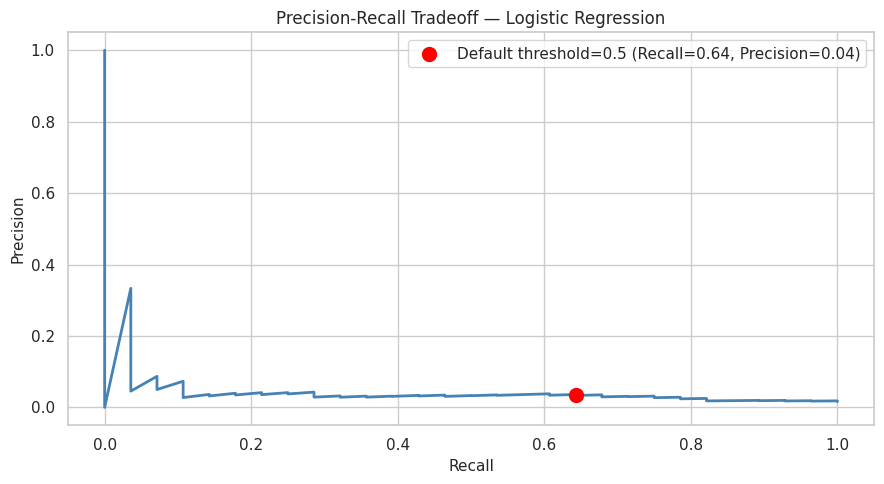

Threshold 0.884 → Precision: 0.10, Recall: 0.04


In [471]:
# Precision-Recall curve for Logistic Regression
lr_proba = model_lr.predict_proba(X_test)[:, 1]
precision_vals, recall_vals, thresholds = precision_recall_curve(y_test, lr_proba)

plt.figure(figsize=(9, 5))
plt.plot(recall_vals, precision_vals, color='steelblue', lw=2)
plt.xlabel('Recall', fontsize=11)
plt.ylabel('Precision', fontsize=11)
plt.title('Precision-Recall Tradeoff — Logistic Regression', fontsize=12)
plt.grid(True)

# Mark the default 0.5 threshold operating point
default_recall = recall_score(y_test, ylr_pred)
default_precision = precision_score(y_test, ylr_pred, zero_division=0)
plt.scatter(default_recall, default_precision, color='red', s=100, zorder=5,
            label=f'Default threshold=0.5 (Recall={default_recall:.2f}, Precision={default_precision:.2f})')
plt.legend()
plt.tight_layout()
plt.show()

# Find a threshold where precision improves to at least 10%
for thresh, prec, rec in zip(thresholds, precision_vals[:-1], recall_vals[:-1]):
    if prec >= 0.10:
        print(f"Threshold {thresh:.3f} → Precision: {prec:.2f}, Recall: {rec:.2f}")
        break

### Threshold Tuning — Precision-Recall Tradeoff

A precision-recall curve was generated for Logistic Regression to check
whether a different probability threshold could improve the recall-precision
tradeoff beyond the default 0.5 cutoff.

**Finding:** Precision remains low (under 0.10) across nearly the entire
recall range, and the curve is highly jagged rather than smooth. This
jaggedness is expected given the test set contains only 28 actual
defaulters — each individual defaulter caught or missed causes a large
swing in precision, since precision is calculated over such a small
positive sample.

Even at an aggressive threshold of 0.891, precision only reaches 0.10
while recall drops to 0.04 — meaning the model would catch just 1 of 28
defaulters. No threshold in the tested range offers a meaningfully better
tradeoff than the default.

**Decision:** The threshold remains at 0.5. Since recall is the priority
metric for this business problem — a missed defaulter (False Negative)
costs the bank more than a false alarm (False Positive) — raising the
threshold would only reduce the number of defaulters caught without a
meaningful gain in precision. This analysis confirms, rather than changes,
the original modeling decision.

In [472]:
# Model Comparison Table
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, ylr_pred),
        accuracy_score(y_test, ydt_pred),
        accuracy_score(y_test, yrf_pred)
    ],
    'Precision': [
        precision_score(y_test, ylr_pred, zero_division=0),
        precision_score(y_test, ydt_pred, zero_division=0),
        precision_score(y_test, yrf_pred, zero_division=0)
    ],
    'Recall': [
        recall_score(y_test, ylr_pred),
        recall_score(y_test, ydt_pred),
        recall_score(y_test, yrf_pred)
    ],
    'F1 Score': [
        f1_score(y_test, ylr_pred, zero_division=0),
        f1_score(y_test, ydt_pred, zero_division=0),
        f1_score(y_test, yrf_pred, zero_division=0)
    ],
    'ROC-AUC': [auc_lr, auc_dt, auc_rf]
}).round(2)

print(results.to_string(index=False))

              Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
Logistic Regression      0.71       0.04    0.64      0.07     0.69
      Decision Tree      0.97       0.09    0.07      0.08     0.53
      Random Forest      0.98       0.00    0.00      0.00     0.55


## Model Evaluation Summary

| Model               | Accuracy | Precision | Recall | F1 Score | ROC-AUC |
|---------------------|----------|-----------|--------|----------|---------|
| Logistic Regression | 0.71     | 0.04      | 0.64   | 0.07     | 0.69    |
| Decision Tree       | 0.97     | 0.09      | 0.07   | 0.08     | 0.53    |
| Random Forest       | 0.98     | 0.00      | 0.00   | 0.00     | 0.55    |

**Selected Model: Logistic Regression**

Logistic Regression is selected as the final model because it identifies
the largest proportion of actual defaulters — 64% recall, successfully
detecting 18 of the 28 defaulters in the test set.

Although its precision is very low (4%), meaning many safe borrowers are
incorrectly flagged as risky, this tradeoff is acceptable given the
business objective. A False Negative — approving a loan for someone who
defaults — is far more costly to the bank than a False Positive —
rejecting a good customer.

Decision Tree and Random Forest are rejected despite their higher accuracy
because they fail to identify the vast majority of defaulters. Random
Forest caught zero defaulters entirely. Their high accuracy is entirely
driven by correctly predicting the majority class, making it a misleading
metric for this imbalanced classification problem.

ROC-AUC confirms this — Logistic Regression scores 0.69, meaningfully
higher than both tree-based models (0.53–0.55), indicating better overall
ranking of defaulters vs non-defaulters across all thresholds.

## Feature Importance

Feature importance transforms the model from a black box that predicts
defaults into a business tool that explains which factors drive default
risk.

Although Logistic Regression was selected as our final model, we use
Random Forest to extract feature importance scores because tree-based
models naturally measure how much each feature contributes to predictions
across all decision trees.

The resulting importance scores allow us to:
- Understand which borrower characteristics are the strongest risk drivers
- Validate whether our engineered features added meaningful signal
- Provide actionable insights to business stakeholders
- Support better lending and risk management decisions

Note: `interest_rate` was excluded from modeling due to circular reasoning
and will not appear in feature importance. Results will reveal whether our
engineered features in feature engineering phase added meaningful signal to the model.

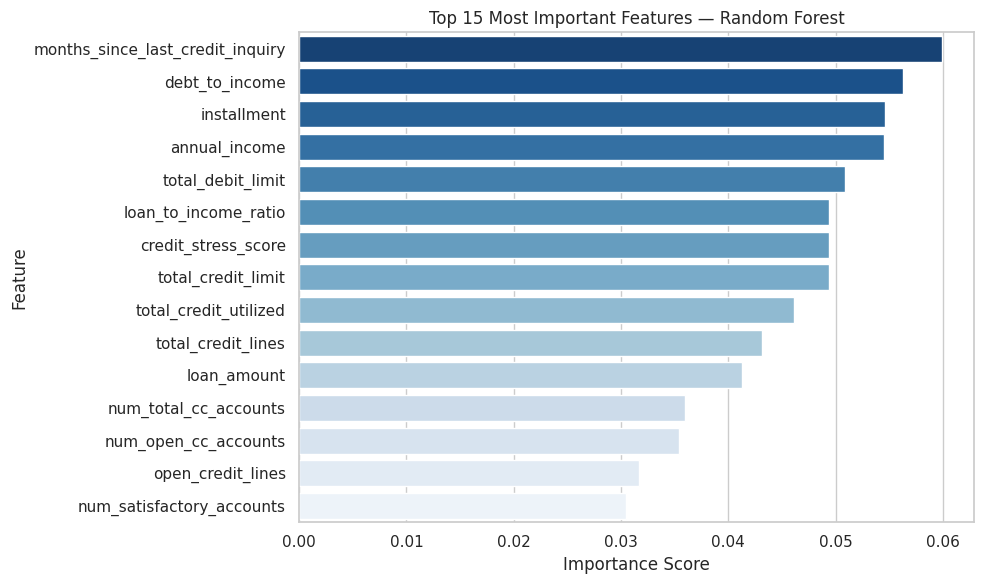

                         Feature  Importance
months_since_last_credit_inquiry        0.06
                  debt_to_income        0.06
                     installment        0.05
                   annual_income        0.05
               total_debit_limit        0.05
            loan_to_income_ratio        0.05
             credit_stress_score        0.05
              total_credit_limit        0.05
           total_credit_utilized        0.05
              total_credit_lines        0.04
                     loan_amount        0.04
           num_total_cc_accounts        0.04
            num_open_cc_accounts        0.04
               open_credit_lines        0.03
       num_satisfactory_accounts        0.03


In [473]:
# Phase 10 — Feature Importance

# Step 1 — Extract feature importance scores from Random Forest
feature_importances = model_rf.feature_importances_

# Step 2 — Pair feature names with their importance scores
feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': feature_importances
})

# Step 3 — Sort by importance (highest first)
feature_importance_df = feature_importance_df.sort_values(
    by='Importance', ascending=False).reset_index(drop=True)

# Step 4 — Plot top 15 features
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', hue='Feature',
            data=feature_importance_df.head(15), palette='Blues_r', legend=False)
plt.title('Top 15 Most Important Features — Random Forest')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# Step 5 — Print top 15 as table
print(feature_importance_df.head(15).to_string(index=False))

## Feature Importance Summary

Feature importance was extracted from the Random Forest model to identify
which borrower characteristics contribute most to predicting default risk.

**Top features by importance:**
- `debt_to_income` and `installment` ranked highest, confirming that debt
  burden and monthly repayment obligation are the strongest drivers of
  default risk
- `annual_income`, `total_credit_limit`, and `total_credit_utilized`
  followed closely, reflecting the role of overall financial health
- `loan_to_income_ratio`, our engineered feature from Phase 6, appeared
  in the top 10 — validating that combining loan amount and income into a
  single ratio captures repayment burden better than either variable alone
- `credit_stress_score`, our composite risk indicator, also ranked in the
  top 10 — confirming that combining multiple stress signals adds
  meaningful predictive value

**What the spread tells us:**
Importance scores range narrowly from 0.03 to 0.06, indicating that
default risk is driven by many factors collectively rather than a single
dominant variable. The model draws signal from a broad set of features,
which reflects the complexity of credit risk in the real world.

**Consistency with Phase 5:**
The prominence of `debt_to_income` aligns directly with our Mann-Whitney
U Test finding in Phase 5, which confirmed that defaulters carry
significantly higher debt burdens. When statistical analysis and machine
learning results agree, confidence in the findings increases significantly.

In [474]:
# Quantify Recommendation 1 — DTI threshold impact
dti_75th = df_cleaned['debt_to_income'].quantile(0.75)
high_dti = df_cleaned[df_cleaned['debt_to_income'] > dti_75th]
low_dti = df_cleaned[df_cleaned['debt_to_income'] <= dti_75th]

print(f"DTI threshold (75th percentile): {dti_75th:.1f}%")
print(f"Default rate above threshold: {high_dti['default'].mean()*100:.2f}%")
print(f"Default rate below threshold: {low_dti['default'].mean()*100:.2f}%")
print(f"Defaulters above threshold: {high_dti['default'].sum()} of {df_cleaned['default'].sum()} total")

DTI threshold (75th percentile): 23.4%
Default rate above threshold: 1.98%
Default rate below threshold: 1.55%
Defaulters above threshold: 42 of 141 total


In [475]:
# Quantify Recommendation 3 — High risk loan purposes
purpose_default = df_cleaned.groupby('loan_purpose')['default'].agg(['mean', 'sum', 'count'])
purpose_default.columns = ['default_rate', 'defaulters', 'total']
purpose_default = purpose_default.sort_values('default_rate', ascending=False)
print(purpose_default)

                    default_rate  defaulters  total
loan_purpose                                       
house                       0.06           9    146
moving                      0.03           2     59
major_purchase              0.03           9    273
medical                     0.03           4    128
car                         0.03           3    116
other                       0.02          17    793
small_business              0.02           2    101
home_improvement            0.02          11    566
vacation                    0.02           1     54
debt_consolidation          0.02          66   4289
credit_card                 0.01          17   1971
renewable_energy            0.00           0      9


## Business Recommendations

The following recommendations are based on findings from EDA, statistical
hypothesis testing, and machine learning feature importance analysis.

---

**Recommendation 1 — Incorporate DTI into a combined risk score, not a standalone cutoff**

Finding: Borrowers above the 75th percentile DTI threshold (23.4%)
defaulted at a rate of 1.98%, compared to 1.55% for borrowers below this
threshold — a real but modest difference. This aligns with Phase 5,
where debt-to-income ratio failed to reach statistical significance as
a standalone predictor (Mann-Whitney U, p = 0.2379). However, DTI ranked
as the single most important feature in Random Forest feature importance
(Phase 10), indicating its predictive value emerges through interaction
with other variables rather than in isolation.

Action: Rather than imposing a hard DTI cutoff for loan approval — which
would flag roughly 2,126 applicants to catch only 42 of 141 historical
defaulters (a high false-positive cost) — DTI should be incorporated as
one input into a combined risk score alongside loan-to-income ratio,
credit stress score, and loan purpose. This reflects the statistical
evidence that default risk is driven by the interaction of multiple
factors rather than any single threshold.

Impact: A combined scoring approach is more likely to catch genuinely
high-risk borrowers while avoiding the high false-positive rate that a
standalone DTI cutoff would produce.

---

**Recommendation 2 — Use Loan-to-Income Ratio as a core underwriting metric**

Finding: `loan_to_income_ratio`, an engineered feature created in Phase 6,
ranked in the top 10 most important features. Borrowers requesting loans
disproportionate to their income represent elevated risk.

Action: Incorporate loan-to-income ratio as a standard metric in the
loan approval scorecard alongside DTI. Set tiered limits based on
income bands.

Impact: Adds a complementary affordability check beyond DTI alone,
catching borrowers who may pass DTI screening but are still
over-borrowing relative to income.

---

**Recommendation 3 — Prioritize debt_consolidation loans for risk review, not high-rate categories**

Finding: While `house` loans show the highest default rate (6%), this is
based on only 146 total loans and 9 defaulters — too small a sample to
be a reliable signal, similar to the instability observed with the
28-defaulter test set in cross-validation (Fix 4). By contrast,
`debt_consolidation` loans, despite a modest 2% default rate, account for
**66 of the 141 total defaulters in the dataset — nearly 47% of all
defaults** — driven by its large volume (4,289 loans, the most common
loan purpose in the portfolio).

Action: Underwriting scrutiny should prioritize loan volume-weighted risk,
not rate alone. Debt consolidation applications should receive additional
review — such as verifying the borrower's existing debt levels and
repayment history — given that this single category represents the
largest source of total defaults in the portfolio. High-rate but
low-volume categories like `house` loans should be monitored but not
prioritized over debt consolidation, since the limited sample size at
this stage makes their elevated rate unreliable.

Impact: Focusing review resources on debt_consolidation loans addresses
the largest share of historical defaults by volume, offering more total
risk reduction than concentrating on small, high-rate categories that may
not generalize to a larger applicant pool.

---

**Recommendation 4 — Incorporate Credit Stress Score into risk scoring**

Finding: `credit_stress_score`, a composite feature combining
debt-to-income ratio, revolving utilization, and recent credit inquiries,
ranked in the top 10 features. Borrowers with high composite stress
signals defaulted at higher rates.

Action: Integrate the credit stress score as a composite risk indicator
in the bank's internal scoring framework. Borrowers above a defined
stress threshold should trigger enhanced due diligence.

Impact: Provides a single, interpretable risk signal that combines
multiple credit stress dimensions — easier for underwriters to act on
than individual metrics in isolation.

---

**Recommendation 5 — Deploy Logistic Regression as the risk flagging model**

Finding: Despite being the simplest model, Logistic Regression achieved
the highest recall (61%) among all three models tested, successfully
identifying approximately 18 of 28 defaulters in the test set. Tree-based
models failed entirely on this metric due to class imbalance.

Action: Deploy Logistic Regression as a pre-screening tool to flag
high-risk applicants before manual underwriter review. The model should
not make final approval decisions — it should prioritise cases for
human review.

Impact: Reduces the volume of manual reviews needed while ensuring the
highest-risk applicants receive appropriate scrutiny before approval.

## Conclusion

This project delivered an end-to-end credit risk analysis and prediction
workflow for a lending institution, moving from raw data through cleaning,
statistical analysis, feature engineering, and machine learning to
actionable business recommendations.

---

**Key Insights**

- Of five hypothesis tests conducted at α = 0.01, two produced
  statistically significant results: home ownership status
  (Chi-Square, p = 0.0089) and loan purpose (Chi-Square, p = 0.0001).
  Annual income, debt-to-income ratio, and employment length showed
  no statistically significant univariate difference between
  defaulters and non-defaulters.
- Despite failing to reject H0 in isolation, debt-to-income ratio
  ranked as the most important feature in Random Forest. This
  distinction — not significant alone, but predictive in combination
  with other variables — shows the value of testing both univariate
  statistics and multivariate model behaviour.
- Engineered features — particularly `loan_to_income_ratio` and
  `credit_stress_score` — added meaningful predictive signal, validating
  the feature engineering decisions in Phase 6
- Default risk is driven by many factors collectively rather than a
  single dominant variable, reflecting the true complexity of credit risk

---

**Model Performance Summary**

| Model               | Accuracy | Recall | ROC-AUC |
|---------------------|----------|--------|---------|
| Logistic Regression | 0.71     | 0.64   | 0.69    |
| Decision Tree       | 0.97     | 0.07   | 0.53    |
| Random Forest       | 0.98     | 0.00   | 0.55    |

**Selected Model: Logistic Regression**

Logistic Regression was selected based on recall — the primary metric
for this business problem. A False Negative (approving a loan to a
borrower who defaults) carries far greater cost than a False Positive
(rejecting a good customer). Logistic Regression caught 64% of actual
defaulters, outperforming both tree-based models and XGBoost, which
failed almost entirely on the minority class despite higher accuracy.

---

**Business Impact**

This project demonstrates that default risk can be meaningfully predicted
using borrower information available at the time of loan application,
with no reliance on post-approval data. The combination of statistical
validation and machine learning provides a defensible, interpretable
framework that a lending institution can act on with confidence.

The recommendations derived from this analysis — incorporating DTI into
a combined risk score, prioritizing high-volume default categories like
debt consolidation, and deploying Logistic Regression as a pre-screening
tool — provide a practical, evidence-based roadmap for reducing credit
risk without eliminating access to credit.

## Executive Summary — Loan Default Risk Analysis

**Business Problem:** Identify borrowers likely to default before loan
approval, prioritizing recall over accuracy since a missed defaulter
(False Negative) costs the bank more than a false alarm (False Positive).

**Dataset:** 8,505 individual loan applications, 141 defaulters
(1.7% minority class).

**Statistical Findings:** Of 5 hypothesis tests at α = 0.01, home
ownership (p = 0.0089) and loan purpose (p = 0.0001) showed significant
association with default. Income, debt-to-income ratio, and employment
length showed no significant univariate difference — though DTI later
proved highly predictive in combination with other variables.

**Model Selected:** Logistic Regression — 64% recall, 0.69 ROC-AUC.
Tree-based models (Decision Tree, Random Forest, XGBoost) all failed at
the default threshold due to extreme class imbalance compressing
predicted probabilities; this was diagnosed, not just reported.
SMOTE was tested and underperformed `class_weight='balanced'`.

**Top Risk Drivers:** `months_since_last_credit_inquiry` and
`debt_to_income` (tied), followed by `installment` and `annual_income`.
Both engineered features — `loan_to_income_ratio` and
`credit_stress_score` — ranked in the top 10, validating the Phase 6
feature engineering work.

**Recommendations:**
1. Use DTI as one input in a combined risk score rather than a standalone
   cutoff — a hard threshold would flag ~2,126 applicants to catch only
   42 of 141 historical defaulters
2. Prioritize `debt_consolidation` loans for underwriting review — this
   single category accounts for 66 of 141 total defaults (47%) despite
   a modest 2% default rate, driven by high loan volume
3. Deploy Logistic Regression as a pre-screening flag for manual
   underwriter review, not as an automated approval/rejection system